# P6 – Prédire la consommation d’énergie des bâtiments

**La Mission**

Aider la ville de Seattle à atteindre son objectif "zéro carbone" en créant un modèle capable de **prédire la consommation d'énergie** des bâtiments **non-résidentiels**.

**Les Données**

Un jeu de données de **3376 bâtiments** pour l'année 2016, décrivant leurs caractéristiques (taille, usage, année de construction, etc.).

**Notre Démarche en 5 Étapes**

| Étape | Description |
| :--- | :--- |
| **1. Nettoyage** | Identifier et corriger les incohérences pour fiabiliser les données. |
| **2. Feature Engineering** | Transformer les données brutes en variables pertinentes pour le modèle. |
| **3. Modélisation** | Comparer plusieurs algorithmes et choisir le plus performant (`RandomForest`). |
| **4. Optimisation** | Affiner le modèle pour améliorer sa précision et sa robustesse. |
| **5. Interprétation** | Comprendre *quels facteurs* influencent le plus la consommation pour proposer des actions concrètes. |

## 1. Analyse exploratoire et nettoyage des données
**Objectif :** comprendre la structure du dataset, identifier les valeurs aberrantes et préparer les données pour la phase de feature engineering.

### 1.1. Environnement et configuration

#### 1.1.1 Importation des librairies

In [472]:
import seaborn as sns 
import sys
sys.path.append("../")

from utils.tools import *
import helper

#### 1.1.2 ⚙️ Configuration globale

In [473]:
# For a better view
sns.set_style("whitegrid")
DATA_FILE_PATH = "../data/raw/2016_Building_Energy_Benchmarking.csv"

# Choix de la cible
TARGET_COL = 'SiteEnergyUse(kBtu)'

Q_THRESHOLD = 0.99
MIN_FREQ_THRESHOLD = 10
RANDOM_STATE = 19
TEST_SIZE = 0.2
DO_GRID_SEARCH = False
OH_ENCODER_DROP_FIRST = False

TEST_FILE_PATH = f"../data/processed/test_data_rs_{RANDOM_STATE}.csv"

### 1.2. Chargement et aperçu Initial

In [474]:
df_building = pd.read_csv(DATA_FILE_PATH)
df_building_raw = df_building.copy()

In [475]:
# On regarde comment un batiment est défini dans ce jeu de données 
print_md(
    "**Head**",
    df_building.head()
)
print_md(f"**Shape: {df_building.shape}**")

**Head**

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,"98,101.000",0659000030,...,"1,156,514.250","3,946,027.000","12,764.529","1,276,453.000",False,NaN,Compliant,NaN,249.980,2.830
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,"98,101.000",0659000220,...,"950,425.188","3,242,851.000","51,450.816","5,145,082.000",False,NaN,Compliant,NaN,295.860,2.860
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,"98,101.000",0659000475,...,"14,515,435.000","49,526,664.000","14,938.000","1,493,800.000",False,NaN,Compliant,NaN,"2,089.280",2.190
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,"98,101.000",0659000640,...,"811,525.312","2,768,924.000","18,112.131","1,811,213.000",False,NaN,Compliant,NaN,286.430,4.670
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,"98,121.000",0659000970,...,"1,573,448.625","5,368,607.000","88,039.984","8,803,998.000",False,NaN,Compliant,NaN,505.010,2.880


**Shape: (3376, 46)**

In [476]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
df_building.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

### 1.3. 🧹Nettoyage préliminaire

**Objectif :** Identifier et corriger les premières anomalies du dataset avant l’analyse approfondie.

**Étapes :**
- Repérage des colonnes peu informatives ou redondantes,  
- Gestion des valeurs manquantes,  
- Suppression des incohérences évidentes.


#### 1.3.1 Suppression des colonnes à faible variance

Certaines colonnes présentent une seule modalité ou une variabilité quasi nulle ➜ elles sont retirées pour éviter le bruit et réduire la dimensionnalité.

In [477]:
# Selectionne les colonnes avec une seule valeur unique - aucune valeur analytique
s_low_cardinality = (df_building.nunique() == 1)
cols_to_drop = s_low_cardinality[s_low_cardinality].index.to_list()
print(f"Colonnes à supprimer: {cols_to_drop}")

Colonnes à supprimer: ['DataYear', 'City', 'State']


In [478]:
# Supprime ces colonnes
with cols_decrease("df_building",verbose=True): # Déclaration d'intention
    df_building = df_building.drop(columns=cols_to_drop)

✅ df_building: (3376, 46) → (3376, 43)
   ➕ Added columns: None
   ➖ Removed columns: DataYear, State, City
   ↔️  Rows unchanged


#### 1.3.2. Suppression des colonnes sans valeur analytique

In [479]:
cols_to_drop = [
    "OSEBuildingID",                # Identifiant technique (pas prédictif)
    "Address",                      # Adresse textuelle non normalisée
    "TaxParcelIdentificationNumber",# Identifiant administratif unique
    "Comments",                     # Colonne vide
    "Outlier" ,                     # Flag temporaire d'analyse
    "YearsENERGYSTARCertified"      # Colonne quasiement vide
]

# Calcul des métriques
df_analysis = pd.DataFrame({
    'column_name': cols_to_drop,
    'fill_rate (%)': [round(df_building[col].notna().mean() * 100, 2) for col in cols_to_drop],
    'cardinality_rate (%)': [round(df_building[col].nunique() / len(df_building) * 100, 2) for col in cols_to_drop]
}).set_index('column_name')
df_analysis


,fill_rate (%),cardinality_rate (%)
column_name,,
OSEBuildingID,100.000,100.000
Address,100.000,99.350
TaxParcelIdentificationNumber,100.000,96.800
Comments,0.000,0.000
Outlier,0.950,0.060
YearsENERGYSTARCertified,3.520,1.930


In [480]:
# Supprime ces colonnes
with cols_decrease("df_building",verbose=True): # Déclaration d'intention
    df_building = df_building.drop(columns=cols_to_drop)

✅ df_building: (3376, 43) → (3376, 37)
   ➕ Added columns: None
   ➖ Removed columns: Outlier, OSEBuildingID, YearsENERGYSTARCertified, TaxParcelIdentificationNumber, Address, Comments
   ↔️  Rows unchanged


### 1.4. Organisation des colonnes par groupes

**Objectif** : Structurer les variables par thématiques pour faciliter l’analyse et les filtres.

Un script utilitaire `get_existing_columns()` assure la mise à jour de ces listes au fur et à mesure du nettoyage.

In [481]:
# 🗺️ Caractéristiques liées à la localisation
location_features = [
    'CouncilDistrictCode',
    'Neighborhood',
    'Latitude',
    'Longitude',
    'ZipCode'    
]

# 🏗️ Caractéristiques structurelles du bâtiment
structural_features = [
    'YearBuilt',
    'NumberofBuildings',
    'NumberofFloors',
    'PropertyGFATotal',
    'PropertyGFAParking',
    'PropertyGFABuilding(s)'
]

# 📋 Caractéristiques liées à l'usage du bâtiment
usage_features = [
    'PropertyName',
    'BuildingType',
    'PrimaryPropertyType',
    'ListOfAllPropertyUseTypes',
    'LargestPropertyUseType',
    'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseType',
    'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseType',
    'ThirdLargestPropertyUseTypeGFA'
]

# ⭐ Caractéristiques de performance et de conformité
rating_features = [
    'ENERGYSTARScore',
    'DefaultData',
    'ComplianceStatus'
]

# 🎯 Cibles potentielles et colonnes à risque de "data leakage"
# Ces colonnes ne doivent PAS être utilisées comme features pour prédire la consommation ou les émissions.
target_and_leaks = [
    'SiteEUI(kBtu/sf)',
    'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)',
    'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUse(kBtu)',       # Cible potentielle
    'SiteEnergyUseWN(kBtu)',
    'SteamUse(kBtu)',
    'Electricity(kWh)',
    'Electricity(kBtu)',
    'NaturalGas(therms)',
    'NaturalGas(kBtu)',
    'TotalGHGEmissions',         # Cible potentielle
    'GHGEmissionsIntensity'
]

In [482]:
# Vérification d'integritée
all_cols = (
                set(location_features)
                | set(structural_features)
                | set(usage_features)
                | set(rating_features)
                | set(target_and_leaks)
)
[col for col in df_building.columns.to_list() if col not in all_cols]

missing_cols = [col for col in all_cols if col not in df_building.columns]


assert not missing_cols, f"⚠️ Colonnes manquantes dans df_building : {missing_cols}"
print("✅ Toutes les colonnes attendues sont bien présentes dans df_building ✅")

✅ Toutes les colonnes attendues sont bien présentes dans df_building ✅


### 1.5. Filtrage du périmètre : Focus sur les bâtiments non-résidentiels

Nous ciblons explicitement les bâtiments **non destinés à l'habitation**. Un filtrage en deux étapes est appliqué pour garantir un périmètre d'étude propre.
 
 **Étape 1 : Filtrage Grossier sur `BuildingType`**
 *   **Action :** Exclusion des catégories explicitement résidentielles (`Multifamily...`).
 *   **Impact :** `3376` → `1668` lignes.
 
 **Étape 2 : Filtrage de Précision par Regex**
 *   **Problème :** Certains bâtiments classés `NonResidential` ont en réalité un usage principal résidentiel (ex: `LargestPropertyUseType` = `Multifamily Housing`).
 *   **Action :** Exclusion de toute ligne contenant `Family|Residence|Residential` dans ses colonnes d'usage.
 *   **Impact :** `1668` → `1628` lignes.
 
 **Résultat :** Le jeu de données final ne contient que des bâtiments à usage commercial, institutionnel ou industriel.

In [483]:
df_building[usage_features].head()

,PropertyName,BuildingType,PrimaryPropertyType,ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA
0,Mayflower park hotel,NonResidential,Hotel,Hotel,Hotel,"88,434.000",NaN,NaN,NaN,NaN
1,Paramount Hotel,NonResidential,Hotel,"Hotel, Parking, Restaurant",Hotel,"83,880.000",Parking,"15,064.000",Restaurant,"4,622.000"
2,5673-The Westin Seattle,NonResidential,Hotel,Hotel,Hotel,"756,493.000",NaN,NaN,NaN,NaN
3,HOTEL MAX,NonResidential,Hotel,Hotel,Hotel,"61,320.000",NaN,NaN,NaN,NaN
4,WARWICK SEATTLE HOTEL (ID8),NonResidential,Hotel,"Hotel, Parking, Swimming Pool",Hotel,"123,445.000",Parking,"68,009.000",Swimming Pool,0.000


In [484]:
print_md("**Type de bâtiments disponibles :**")
df_building["BuildingType"].unique().tolist()

**Type de bâtiments disponibles :**

['NonResidential',
 'Nonresidential COS',
 'Multifamily MR (5-9)',
 'SPS-District K-12',
 'Campus',
 'Multifamily LR (1-4)',
 'Multifamily HR (10+)',
 'Nonresidential WA']

#### 1.5.1. Filtrage initial sur `BuildingType`

| Type de Bâtiment (`BuildingType`) | Signification Probable | À inclure ? 🤔 |
| :--- | :--- | :--- |
| `NonResidential` | 🏢 Bâtiment non résidentiel standard | ✅ **Oui** |
| `Nonresidential COS` | 🏛️ Bâtiment non résidentiel appartenant à la Ville de Seattle (City of Seattle) | ✅ **Oui** |
| `SPS-District K-12` | 🏫 École publique de Seattle (Seattle Public Schools) | ✅ **Oui** |
| `Campus` | 🎓 Bâtiment faisant partie d'un campus (université, etc.) | ✅ **Oui** |
| `Nonresidential WA` | 🏢 Bâtiment non résidentiel de l'État de Washington | ✅ **Oui** |
| `Multifamily MR (5-9)` | 🏠 Immeuble résidentiel de taille moyenne (5-9 logements) | ❌ **Non** |
| `Multifamily LR (1-4)` | 🏡 Petit immeuble résidentiel (1-4 logements) | ❌ **Non** |
| `Multifamily HR (10+)` | 🏙️ Grand immeuble résidentiel (10+ logements) | ❌ **Non** |

In [485]:
non_residential_types =[
    'NonResidential', 
    'Nonresidential COS', 
    'SPS-District K-12', 
    'Campus', 
    'Nonresidential WA'
]

df_non_residential = df_building[df_building["BuildingType"].isin(non_residential_types)].copy()

print_md("**La taille de df avant et après le filtrage**")
report_shape_changes(df_building.shape, df_non_residential.shape)
print_md("___")

print_md("**Répartition des types de bâtiments conservés :**")
display(df_non_residential['BuildingType'].value_counts())

**La taille de df avant et après le filtrage**

Shape avant: (3376, 37)
Shape après: (1668, 37)
  ✂️  Lignes supprimées: 1708


___

**Répartition des types de bâtiments conservés :**

BuildingType
NonResidential        1460
SPS-District K-12       98
Nonresidential COS      85
Campus                  24
Nonresidential WA        1
Name: count, dtype: int64

#### 1.5.2. Filtrage de précision sur l'usage réel (`LargestPropertyUseType`)

In [486]:
regex_residential = "Family|Residence|Residential"
mask_residential = (
                (df_non_residential["PrimaryPropertyType"].str.contains(regex_residential, case=False, na=False, regex=True))
                |(df_non_residential["LargestPropertyUseType"].str.contains(regex_residential, case=False, na=False, regex=True))
)
df_non_residential.loc[mask_residential, ["PropertyName", "BuildingType", "PrimaryPropertyType", "LargestPropertyUseType", "ListOfAllPropertyUseTypes"]].head()

,PropertyName,BuildingType,PrimaryPropertyType,LargestPropertyUseType,ListOfAllPropertyUseTypes
113,Hope Place,NonResidential,Other,Other - Lodging/Residential,"Food Service, Office, Other - Lodging/Residential"
115,Emerson Hall,NonResidential,Residence Hall,Residence Hall/Dormitory,Residence Hall/Dormitory
164,TriBeCa,NonResidential,Mixed Use Property,Multifamily Housing,"Financial Office, Multifamily Housing, Parking..."
186,Women's Residence at Seneca,NonResidential,Residence Hall,Residence Hall/Dormitory,"Office, Residence Hall/Dormitory, Retail Store"
644,Pacific Pointe,NonResidential,Low-Rise Multifamily,Multifamily Housing,Multifamily Housing


In [487]:
with rows_decrease("df_non_residential",verbose=True): # Déclaration d'intention
    df_non_residential = df_non_residential.loc[~mask_residential].copy()

✅ df_non_residential: (1668, 37) → (1628, 37)
   ➕ Added columns: None
   ➖ Removed columns: None
   ↘️  Rows decreased by 40 (1668 → 1628)


### 1.6. Harmonisation et Standardisation des Types de Données

 -   **`ZipCode`** : `float` → `string`
     *   *Justification :* C'est un identifiant géographique, pas une valeur numérique.
     *   *Gestion des NaN :* 16 `NaN` (1%) sont conservés. La suppression est évitée car les autres features de localisation (`Neighborhood`, etc.) sont présentes.
 -   **`DefaultData`** : `bool` → `int`
     *   *Justification :* Conversion en format binaire `0`/`1` standard pour la modélisation.
 -   **`CouncilDistrictCode`** : `int` → `string`
     *   *Justification :*  (⚠️ **Action critique.**) C'est une **catégorie**, pas une valeur ordinale. Laisser en `int` aurait créé une fausse relation d'ordre.

- **`Neighborhood`** : (standardisée)  
  - **Justification** : Standardisation de la casse avant encodage pour éviter les doublons (ex. `'BALLARD'` => `'Ballard'`).   

#### 1.6.1. `Zipcode` : float => string

In [488]:
df_non_residential["ZipCode"] = df_non_residential["ZipCode"].dropna().astype(int).astype(str)
display_stats(df_non_residential, "ZipCode")

---

**Colonne: ZipCode**

🔍 Type réel: object
📊 Mémoire: 0.10 MB
Longueur min du texte: 5
Longueur max du texte: 5
Valeurs uniques: 48
Valeurs les plus fréquentes:


,count
ZipCode,
98134,181
98104,152
98101,146
98109,139
98108,120


⚠️ Il y a 16 valeurs manquantes dans la colonne 'ZipCode' soit 1.0%


In [489]:
mask = df_non_residential["ZipCode"].isna()
df_non_residential.loc[mask,location_features]

,CouncilDistrictCode,Neighborhood,Latitude,Longitude,ZipCode
3360,5,NORTH,47.705,-122.322,NaN
3361,3,CENTRAL,47.599,-122.298,NaN
3362,6,BALLARD,47.693,-122.377,NaN
3363,5,NORTH,47.721,-122.297,NaN
3364,6,BALLARD,47.673,-122.392,NaN
3365,6,BALLARD,47.677,-122.376,NaN
3366,7,MAGNOLIA / QUEEN ANNE,47.636,-122.375,NaN
3367,3,EAST,47.632,-122.316,NaN
3368,3,CENTRAL,47.608,-122.302,NaN
3369,2,SOUTHEAST,47.564,-122.278,NaN


#### 1.6.2. `DefaultData` : bool => int

In [490]:
df_non_residential["DefaultData"] = df_non_residential["DefaultData"].astype(int)

#### 1.6.3. `CouncilDistrictCode` : int => obj 

In [491]:
df_non_residential["CouncilDistrictCode"]  = df_non_residential["CouncilDistrictCode"].astype("str")

#### 1.6.4. Standardisation de feature `Neighborhood` : (ex. `'BALLARD'` => `'Ballard'`). 

In [492]:
# On standardise la casse avant l'encodage pour éviter les catégories en double (ex: 'BALLARD' et 'Ballard').
df_non_residential['Neighborhood'] = df_non_residential['Neighborhood'].str.title()
print("✅ Casse de la colonne 'Neighborhood' standardisée.")

✅ Casse de la colonne 'Neighborhood' standardisée.


### 1.7. Analyse Approfondie et Nettoyage des Types d'Usage

#### 1.7.1. Export pour Analyse Manuelle des Usages
**Justification :** Cette étape a permis une analyse hors-notebook des différentes catégories d'usage, ce qui a conduit aux décisions stratégiques suivantes.

In [493]:
# Export des type d'usage pour analyse
helper.export_use_type_summary(
    df=df_non_residential,
    columns=[
        "ListOfAllPropertyUseTypes",
        "PrimaryPropertyType",
        "LargestPropertyUseType",
        "SecondLargestPropertyUseType",
        "ThirdLargestPropertyUseType",
    ],
    output_path = '../data/outputs/use_type_per_columns.csv',
    overwrite=False
)

✅ Fichier déjà existant : ../data/outputs/use_type_per_columns.csv


#### 1.7.2. Synthèse de la Décision : Choix de la Colonne de Référence

Les colonnes `PrimaryPropertyType` et `LargestPropertyUseType` sont redondantes. 

Après analyse `PrimaryPropertyType` est écartée car **15% de ses valeurs sont 'Other'**, contre seulement **6%** pour `LargestPropertyUseType` avant imputation. De plus, `PrimaryPropertyType` contient des catégories redondantes avec la surface (ex: 'Large Office'), tandis que `LargestPropertyUseType` se concentre sur la **fonction** du bâtiment.

| Critère d'Évaluation | 👎 `PrimaryPropertyType` (Colonne abandonnée) | 👍 `LargestPropertyUseType` (Colonne adoptée) |
| :--- | :--- | :--- |
| **Fiabilité & Précision** | **Faible.** Contient 250 (15%) valeurs `'Other'` vagues et non-informatives. | **Élevée.** Ne contient que 98 (6%) valeurs `'Other'`, qui seront en grande partie corrigées par imputation. |
| **Information Redondante** | **Élevée.** Introduit des notions subjectives comme `'Large'` ou `'Small- and Mid-Sized'` qui sont déjà représentées quantitativement par la surface (`PropertyGFABuilding(s)`). | **Faible.** Se concentre sur la **fonction** du bâtiment (ex: `'Medical Office'`), ce qui est une information unique et complémentaire à la surface. |
| **Utilité pour le Modèle** | **Médiocre.** Les catégories sont mal définies et créent du "bruit", rendant l'apprentissage du modèle moins efficace. | **Excellente.** Fournit des catégories claires et fonctionnelles, idéales pour que le modèle puisse apprendre des patterns solides. |

**Conclusion :** `LargestPropertyUseType` est adoptée comme feature catégorielle principale. Les autres colonnes d'usage serviront de colonnes auxiliaires pour le nettoyage avant d'être supprimées.

#### 1.7.3. Création d'une Colonne d'Usage Composite
**Justification :** Cette colonne au format `list` est une étape préparatoire indispensable pour l'imputation et le futur feature engineering.

In [494]:
with cols_increase("df_non_residential",verbose=True):
    df_non_residential["c_ListOfAllPropertyUseTypes"] = df_non_residential["ListOfAllPropertyUseTypes"].dropna().str.split(', ')

✅ df_non_residential: (1628, 37) → (1628, 38)
   ➕ Added columns: c_ListOfAllPropertyUseTypes
   ➖ Removed columns: None
   ↔️  Rows unchanged


#### 1.7.4. Nettoyage et Fiabilisation de `LargestPropertyUseType`

 Deux opérations de nettoyage sont menées pour améliorer la qualité de notre feature de référence :
 1.  **Gestion des `NaN` :**
     *   **Investigation :** 6 lignes ont une valeur manquante pour `LargestPropertyUseType` ET pour sa surface associée (`LargestPropertyUseTypeGFA`).
     *   **Action :** L'imputation étant impossible, ces 6 lignes sont **supprimées**.
     *   **Impact :** Négligeable (< 0.4% des données).
 2.  **Imputation des `"Other"` :**
     *   **Problème :** 98 bâtiments ont la catégorie vague `"Other"`.
     *   **Action :** Une fonction d'imputation (`helper.impute_other`) utilise les informations des colonnes `PrimaryPropertyType` et `ListOfAllPropertyUseTypes` pour corriger cette valeur lorsque c'est possible.
     *   **Résultat :** **9 valeurs `"Other"` sont corrigées**, réduisant le nombre de cas vagues à 89 et enrichissant le jeu de données.
 **Résultat Final :** La colonne `LargestPropertyUseType` est maintenant propre, sans valeur manquante, et avec un nombre réduit de catégories non informatives.

##### 1.7.4.1. Gestion des valeurs manquantes

In [589]:
n_missing = df_non_residential["LargestPropertyUseType"].isna().sum()
print_md(f" Nombres de **valeurs manquantes** dans la colonne `LargestPropertyUseType`: **{n_missing}**")

 Nombres de **valeurs manquantes** dans la colonne `LargestPropertyUseType`: **0**

In [496]:
# On vérifier si on peut imputer les valeurs NaN
mask = (
            (df_non_residential["LargestPropertyUseType"].isna()) 
            & df_non_residential[["PrimaryPropertyType", "ListOfAllPropertyUseTypes"]].notna().any(axis=1)         
        )
df_non_residential.loc[mask, ['PropertyName', 'LargestPropertyUseType', 'PrimaryPropertyType', 'ListOfAllPropertyUseTypes']]

,PropertyName,LargestPropertyUseType,PrimaryPropertyType,ListOfAllPropertyUseTypes
353,Market St Center,NaN,Self-Storage Facility,"Fitness Center/Health Club/Gym, Office, Other ..."
578,SEATTLE BUILDING,NaN,Small- and Mid-Sized Office,NaN
1147,Palladian Hotel,NaN,Hotel,Hotel
2414,Talon Northlake LLC,NaN,Small- and Mid-Sized Office,Office
2459,BUSH GARDEN - RESTURANT & LOUNGE,NaN,Restaurant,Restaurant
2670,KALBERG BUILDING,NaN,Mixed Use Property,NaN


In [497]:
# Meme si on impute ces 6 valeurs manquantes le superficie manquera.Donc on prends la décision de les supprimer.
mask = df_non_residential["LargestPropertyUseType"].isna()
df_non_residential.loc[mask, ["LargestPropertyUseType", "LargestPropertyUseTypeGFA"]]

,LargestPropertyUseType,LargestPropertyUseTypeGFA
353,NaN,NaN
578,NaN,NaN
1147,NaN,NaN
2414,NaN,NaN
2459,NaN,NaN
2670,NaN,NaN


In [498]:
with rows_decrease("df_non_residential", verbose=True):
    df_non_residential = df_non_residential.dropna(subset="LargestPropertyUseType")

✅ df_non_residential: (1628, 38) → (1622, 38)
   ➕ Added columns: None
   ➖ Removed columns: None
   ↘️  Rows decreased by 6 (1628 → 1622)


##### 1.7.4.2. Imputation des valeurs "Other"

In [499]:
mask = (
            (df_non_residential["LargestPropertyUseType"] =="Other") 
            &
            (
               ~(df_non_residential["PrimaryPropertyType"].str.contains("Other", na=False))
            |  ~(df_non_residential["ListOfAllPropertyUseTypes"].str.contains("Other", na=False))
            )
        )
result = df_non_residential.loc[mask, ['PropertyName', 'LargestPropertyUseType', 'PrimaryPropertyType', 'ListOfAllPropertyUseTypes']].copy()
result["ListOfAllPropertyUseTypes"] = result["ListOfAllPropertyUseTypes"].str.split(", ").str[0]
result

,PropertyName,LargestPropertyUseType,PrimaryPropertyType,ListOfAllPropertyUseTypes
341,307 Westlake - SEDO,Other,Mixed Use Property,Office
395,Richmark Label,Other,Mixed Use Property,Office
529,Western Building,Other,Retail Store,Retail Store
620,childhaven,Other,Mixed Use Property,Office
796,U.S. BANK,Other,Mixed Use Property,Bank Branch
1524,Building C,Other,Mixed Use Property,Non-Refrigerated Warehouse
1900,Elliott Commons,Other,Mixed Use Property,Medical Office
2182,JukeboxCity Building,Other,Mixed Use Property,Other
2248,Hanford Center,Other,Mixed Use Property,Non-Refrigerated Warehouse
3129,(ID#40008) KC Metro Transit Power Distribution,Other,Mixed Use Property,Office


In [500]:
print_md(f"Nombre de valeur `Other` dans LargestPropertyUseType :**{df_non_residential['LargestPropertyUseType'].eq('Other').sum()}**")
old_shape = df_non_residential.shape

df_non_residential = helper.impute_other(df_non_residential, verbose=True, return_changes=False) 

print_md(f"Nombre de valeur `Other` dans LargestPropertyUseType :**{df_non_residential['LargestPropertyUseType'].eq('Other').sum()}**")
report_shape_changes(old_shape, df_non_residential.shape)


Nombre de valeur `Other` dans LargestPropertyUseType :**98**


🔍 9 lignes imputées sur 98 'Other'
 index                                   PropertyName     LargestPropertyUseType OldValue                   NewValue                    Source
   341                            307 Westlake - SEDO                     Office    Other                     Office ListOfAllPropertyUseTypes
   395                                 Richmark Label                     Office    Other                     Office ListOfAllPropertyUseTypes
   529                               Western Building               Retail Store    Other               Retail Store       PrimaryPropertyType
   620                                     childhaven                     Office    Other                     Office ListOfAllPropertyUseTypes
   796                                      U.S. BANK                Bank Branch    Other                Bank Branch ListOfAllPropertyUseTypes
  1524                                     Building C Non-Refrigerated Warehouse    Other Non-Refrigerated

Nombre de valeur `Other` dans LargestPropertyUseType :**89**

Shape avant: (1622, 38)
Shape après: (1622, 38)
  🔄 Aucun changement de dimension


In [501]:
df_non_residential[["LargestPropertyUseType"]].isna().sum().reset_index(name="Nb valeurs manquantes")

,index,Nb valeurs manquantes
0,LargestPropertyUseType,0


### 1.8. Audit & Nettoyage des Features Numériques

Le traitement des variables numériques est une étape critique qui suit plusieurs phases :
    
-  **Nettoyage initial** des valeurs manquantes, nulles et négatives.
-  **Imputation stratégique** des features importantes mais incomplètes (`ENERGYSTARScore`).
-  **Analyse de corrélation et de cohérence** pour valider les relations entre les variables et identifier les redondances.


#### 1.8.1. Nettoyage des Valeurs Aberrantes

-   **Action :** Imputation des `...GFA` par `0`.
-   **Action :** Suppression des `NaN` sur les colonnes d'énergie critiques.
-   **Action :** Imputation des `SiteEnergyUse(kBtu) == 0` par la somme des sources.
-   **Action :** Suppression des lignes avec `NumberofBuildings` ou `NumberofFloors` nuls.

In [502]:
missing_summary(df_non_residential, numeric_only=True, verbose=False)

,col,missing_count,missing_pct
0,ThirdLargestPropertyUseTypeGFA,1282,79.040
1,SecondLargestPropertyUseTypeGFA,787,48.520
2,ENERGYSTARScore,553,34.090
3,SiteEUI(kBtu/sf),1,0.060
4,SiteEUIWN(kBtu/sf),1,0.060
5,SiteEnergyUseWN(kBtu),1,0.060


##### 1.8.1.1. Imputation des `...GFA` par `0`

In [503]:
# Remplacement des NaN par 0 dans les colonnes de surface
cols_gfa = ["ThirdLargestPropertyUseTypeGFA", "SecondLargestPropertyUseTypeGFA"]
df_non_residential[cols_gfa] = df_non_residential[cols_gfa].fillna(0)

##### 1.8.1.2. Suppression des `NaN` sur les colonnes d'énergie critiques.

In [504]:
# Supprimer les NaN des colonnes énergie
cols = ['SiteEUI(kBtu/sf)', "SiteEUIWN(kBtu/sf)", "SiteEnergyUseWN(kBtu)"]
df_non_residential = df_non_residential.dropna(subset=cols)

`ENEGRYSTARScore` sera imputée plus tard

In [505]:
missing_summary(df_non_residential, numeric_only=True, verbose=True)

               col  missing_count  missing_pct
0  ENERGYSTARScore            552       34.070

,col,missing_count,missing_pct
0,ENERGYSTARScore,552,34.070


In [506]:
df_non_residential.dtypes.unique()

array([dtype('O'), dtype('float64'), dtype('int64')], dtype=object)

In [507]:
print_md(
    "**Colonnes numériques**",
    df_non_residential.select_dtypes(include=["int64","float64"]).columns
)

**Colonnes numériques**

Index(['Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)',
       'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)',
       'DefaultData', 'TotalGHGEmissions', 'GHGEmissionsIntensity'],
      dtype='object')

In [508]:
# Features devant être strictement positive (non nulles)
cols_not_null = [
        TARGET_COL, 'YearBuilt', 'NumberofBuildings',
        'NumberofFloors', 'PropertyGFATotal','PropertyGFABuilding(s)',
        'LargestPropertyUseTypeGFA','ENERGYSTARScore'
]
zero_negative_summary(df_non_residential,cols=cols_not_null)

,col,zero_count,negative_count
0,SiteEnergyUse(kBtu),15,0
1,NumberofBuildings,50,0
2,NumberofFloors,12,0


##### 1.8.1.3. Imputation des `SiteEnergyUse(kBtu) == 0` par la somme des sources.

-   **Anomalie Détectée :** Une analyse a révélé la présence de **15 bâtiments** (principalement des écoles) avec une valeur de `SiteEnergyUse(kBtu)` égale à **zéro**. Cette valeur est considérée comme une aberration, probablement due à une erreur de mesure ou de saisie.

-   **Stratégie de Correction :** Plutôt que de supprimer ces lignes, une imputation a été réalisée. La valeur nulle a été remplacée par la **somme des consommations énergétiques par source** (`Electricity`, `NaturalGas`, `Steam`), qui elles, étaient correctement renseignées.

-   **Justification :** Cette approche permet de **conserver ces 15 observations** tout en corrigeant la valeur agrégée erronée avec une estimation fiable et physiquement cohérente.

In [509]:
mask = df_non_residential["SiteEnergyUse(kBtu)"] == 0
df_non_residential.loc[mask, :].head(5)

,BuildingType,PrimaryPropertyType,PropertyName,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,...,SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity,c_ListOfAllPropertyUseTypes
28,SPS-District K-12,K-12 School,Meany Building,98112,3,Central,47.623,-122.305,1955,1.000,...,0.000,0.000,0.000,0.000,0.000,0,Missing Data,0.000,0.000,[K-12 School]
31,SPS-District K-12,K-12 School,John Hay Elementary,98109,7,Magnolia / Queen Anne,47.633,-122.352,1989,1.000,...,0.000,"438,691.688","1,496,816.000",0.000,0.000,0,Missing Data,10.430,0.200,[K-12 School]
62,SPS-District K-12,K-12 School,Arbor Heights Elementary,98146,1,Southwest,47.510,-122.378,1948,1.000,...,0.000,"176,088.094","600,813.000",0.000,0.000,0,Missing Data,4.190,0.080,[K-12 School]
81,SPS-District K-12,K-12 School,Pathfinder K-8,98106,1,Delridge,47.564,-122.358,1999,1.000,...,0.000,"497,706.812","1,698,176.000",0.000,0.000,0,Missing Data,11.840,0.160,[K-12 School]
85,SPS-District K-12,K-12 School,John Muir Elementary,98144,2,Southeast,47.573,-122.291,1991,1.000,...,0.000,"687,906.875","2,347,138.000",0.000,0.000,0,Missing Data,16.360,0.280,[K-12 School]


In [510]:
with shape_same("df_non_residential"):
    mask = df_non_residential["SiteEnergyUse(kBtu)"] == 0
    df_non_residential.loc[mask, "SiteEnergyUse(kBtu)"] = df_non_residential.eval("`Electricity(kBtu)` + `NaturalGas(kBtu)` + `SteamUse(kBtu)`")

✅ df_non_residential: Shape unchanged.
   ➕ Added columns: None
   ➖ Removed columns: None
   ↔️  Rows unchanged


Il en reste 4 avec toutes les colonnes énérgies manquantes, nous allons les supprimer.

In [511]:
mask = df_non_residential[TARGET_COL] == 0
df_non_residential.loc[mask, ['SourceEUI(kBtu/sf)','Electricity(kBtu)','NaturalGas(kBtu)','SteamUse(kBtu)']]

,SourceEUI(kBtu/sf),Electricity(kBtu),NaturalGas(kBtu),SteamUse(kBtu)
28,0.000,0.000,0.000,0.000
152,0.000,0.000,0.000,0.000
746,0.000,0.000,0.000,0.000
1361,0.000,0.000,0.000,0.000


In [512]:
with rows_decrease("df_non_residential"):
    df_non_residential = df_non_residential[df_non_residential["SiteEnergyUse(kBtu)"] > 0].copy()

✅ df_non_residential: (1620, 38) → (1616, 38)
   ➕ Added columns: None
   ➖ Removed columns: None
   ↘️  Rows decreased by 4 (1620 → 1616)


In [513]:
# GARDE FOU pour empêcher d’avancer sans nettoyer la cible
is_clean = df_non_residential[TARGET_COL].notna().all() and (df_non_residential[TARGET_COL] > 0).all()
assert is_clean, f"La feature cible `{TARGET_COL}` contient encore des NaN ou des valeurs ≤ 0."

In [514]:
zero_negative_summary(df_non_residential,cols=cols_not_null)

,col,zero_count,negative_count
0,NumberofBuildings,50,0
1,NumberofFloors,12,0


##### 1.8.1.4. Suppression des lignes avec `NumberofBuildings` ou `NumberofFloors` nuls.

- 61 bâtiments présentent des valeurs physiquement impossibles (`NumberofBuildings = 0` ou `NumberofFloors = 0`).
- Ces erreurs de saisie manifestes sont supprimées pour garantir la cohérence structurelle du jeu de données.

In [515]:
cols = [TARGET_COL, 'NumberofBuildings','NumberofFloors']
mask = (df_non_residential[cols] <= 0).any(axis=1)
df_non_residential.loc[mask, cols + ["PropertyName", "BuildingType", "PrimaryPropertyType"]].sort_values(by=['NumberofFloors','NumberofBuildings'], ascending=False)

,SiteEnergyUse(kBtu),NumberofBuildings,NumberofFloors,PropertyName,BuildingType,PrimaryPropertyType
3108,"8,382,140.500",0.000,24,Bay Vista Office Building,NonResidential,Large Office
280,"37,785,552.000",0.000,19,Motif Seattle,NonResidential,Hotel
278,"6,029,020.000",0.000,10,Fourth and Pike Building,NonResidential,Large Office
2963,"17,457,560.000",0.000,10,Hotel1000,NonResidential,Hotel
3205,"41,696,464.000",0.000,8,UW Medicine Phase 3.1,NonResidential,Laboratory
...,...,...,...,...,...,...
3130,"15,206,762.000",1.000,0,Sandpoint #5,NonResidential,Warehouse
3131,"2,193,115.000",1.000,0,Sandpoint #25,NonResidential,Medical Office
3132,"3,947,209.250",1.000,0,Sandpoint #29,NonResidential,Small- and Mid-Sized Office
3273,"2,159,170.250",1.000,0,Smilow Rainier Vista Boys & Girls Club,NonResidential,Other


In [516]:
# --- Suppression finale des 61 lignes avec des données structurelles aberrantes ---

# On crée un masque pour identifier les lignes où NumberofBuildings ou NumberofFloors est <= 0
mask_aberrant_structure = (df_non_residential['NumberofBuildings'] <= 0) | (df_non_residential['NumberofFloors'] <= 0)

# On affiche le nombre de lignes qui seront supprimées pour vérification
print(f"Nombre de lignes avec des aberrations structurelles à supprimer : {mask_aberrant_structure.sum()}")

# On filtre le DataFrame pour ne garder que les lignes valides
with rows_decrease("df_non_residential"):
    df_non_residential = df_non_residential[~mask_aberrant_structure].copy()

Nombre de lignes avec des aberrations structurelles à supprimer : 61
✅ df_non_residential: (1616, 38) → (1555, 38)
   ➕ Added columns: None
   ➖ Removed columns: None
   ↘️  Rows decreased by 61 (1616 → 1555)


In [517]:
# Garde-fou final pour s'assurer que le nettoyage est complet
assert (df_non_residential['NumberofBuildings'] > 0).all()
assert (df_non_residential['NumberofFloors'] > 0).all()
print("✅ Vérification réussie : plus de valeurs aberrantes pour NumberofBuildings et NumberofFloors.")

✅ Vérification réussie : plus de valeurs aberrantes pour NumberofBuildings et NumberofFloors.


#### 1.8.2. Nettoyage des colonnes redondantes (`Electricity`, `Gas`)

##### 1.8.2.1. Nettoyage des colonnes `Electricity`

*   **Redondance**
    *   **Relation :** `Electricity(kBtu)` ≈ `Electricity(kWh)` \* 3.412 (vérifiée à 99.9%).
    *   **Choix :** Garder `Electricity(kWh)`.
    *   **Raison :** Plus grande précision (valeurs `float` plus granulaires).
    *   **Action :** Suppression de `Electricity(kBtu)`.

*   **Aberration**
    *   **Découverte :** 1 ligne avec `Electricity(kWh)` < 0.
    *   **Raison :** Valeur physiquement impossible (erreur de donnée).
    *   **Action :** Suppression de la ligne.

In [518]:
assert ~df_non_residential[["Electricity(kBtu)", "Electricity(kWh)"]].isna().any().any(), "❌ Il faut nettoyer déjà les valeurs manquantes"
print("✅Aucune valeur manquante")

✅Aucune valeur manquante


In [519]:
_ = check_formula_consistency(
        df_non_residential,
        formulas = {"kBtu = kWh x 3.412" : "`Electricity(kBtu)` = `Electricity(kWh)` * 3.412"},
        rtol = 1e-2,
        atol = 1e-2,
        verbose=True,
        return_df=False
)


⚠️ [kBtu = kWh x 3.412]
│   ├─ Cible : Electricity(kBtu)
│   ├─ Cohérence :  99.94%	| Diff. relative :   0.01%
│   ├─ Diff. moyenne :   0.2464	| Max diff :     0.4995
│   └─ Lignes valides :  1555	| Incohérentes :     1


In [520]:
mask_negative = df_non_residential["Electricity(kWh)"] < 0
if mask_negative.any():
    print_md(f"**Suppréssion** des valeurs **négatives** dans `Electricity(kWh)` : **{mask_negative.sum()}** ligne(s) supprimées ")
    df_non_residential = df_non_residential.loc[~mask_negative]    

**Suppréssion** des valeurs **négatives** dans `Electricity(kWh)` : **1** ligne(s) supprimées 

In [521]:
with cols_decrease("df_non_residential", verbose=True):
    df_non_residential = df_non_residential.drop(columns="Electricity(kBtu)")

✅ df_non_residential: (1554, 38) → (1554, 37)
   ➕ Added columns: None
   ➖ Removed columns: Electricity(kBtu)
   ↔️  Rows unchanged


##### 1.8.2.2. Nettoyage des colonnes `Gas`

*   **Redondance**
    *   **Relation :** `NaturalGas(kBtu)"` ≈ `"NaturalGas(therms)` x 100 (vérifiée à 100%).
    *   **Choix :** Garder `NaturalGas(therms)`.
    *   **Raison :** Plus grande précision (valeurs `float` plus granulaires).
    *   **Action :** Suppression de `NaturalGas(kBtu)`.

In [522]:
assert ~df_non_residential[["NaturalGas(kBtu)", "NaturalGas(therms)"]].isna().any().any(), "❌ Il faut nettoyer déjà les valeurs manquantes"
print("✅Aucune valeur manquante")

✅Aucune valeur manquante


In [523]:
_ = check_formula_consistency(
    df_non_residential,
    formulas = {"kBtu = therms x 100" : "`NaturalGas(kBtu)` = `NaturalGas(therms)` * 100"},
    rtol = 1e-2,
    atol = 1e-2,
    verbose=True
)


✅ [kBtu = therms x 100]
│   ├─ Cible : NaturalGas(kBtu)
│   ├─ Cohérence : 100.00%	| Diff. relative :   0.00%
│   ├─ Diff. moyenne :   0.0738	| Max diff :     0.5000
│   └─ Lignes valides :  1554	| Incohérentes :     0


In [524]:
df_non_residential["NaturalGas(kBtu)"].head()

0   1,276,453.000
1   5,145,082.000
2   1,493,800.000
3   1,811,213.000
4   8,803,998.000
Name: NaturalGas(kBtu), dtype: float64

In [525]:
df_non_residential[["NaturalGas(kBtu)", "NaturalGas(therms)"]].head()

,NaturalGas(kBtu),NaturalGas(therms)
0,"1,276,453.000","12,764.529"
1,"5,145,082.000","51,450.816"
2,"1,493,800.000","14,938.000"
3,"1,811,213.000","18,112.131"
4,"8,803,998.000","88,039.984"


In [526]:
assert ~(df_non_residential["NaturalGas(therms)"] < 0).any(), "❌ Il faut nettoyer déjà les valeurs négatives"
print_md(f"✅Aucune valeur négative dans `NaturalGas(therms)`")

✅Aucune valeur négative dans `NaturalGas(therms)`

In [527]:
with cols_decrease("df_non_residential", verbose=True):
    df_non_residential = df_non_residential.drop(columns="NaturalGas(kBtu)")

✅ df_non_residential: (1554, 37) → (1554, 36)
   ➕ Added columns: None
   ➖ Removed columns: NaturalGas(kBtu)
   ↔️  Rows unchanged


In [528]:
cols = [
    "SiteEUI(kBtu/sf)",
    "SiteEUIWN(kBtu/sf)",
    "SiteEnergyUseWN(kBtu)"
]
mask = df_non_residential[cols].isna().any(axis=1)
target_and_leaks = get_existing_columns(df_non_residential, target_and_leaks, verbose=True)
df_non_residential.loc[mask, target_and_leaks]

⚠️ 2 colonne(s) manquante(s): ['Electricity(kBtu)', 'NaturalGas(kBtu)']


,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),NaturalGas(therms),TotalGHGEmissions,GHGEmissionsIntensity


In [529]:
# Nous supprimons les valeurs manquantes s'il en existe.
if mask.sum() > 0:
    with rows_decrease("df_non_residential", verbose=True):
        df_non_residential = df_non_residential.dropna(subset=target_and_leaks)

In [530]:
assert not df_non_residential[target_and_leaks].isna().any().any()
print("✅ Vérification réussie.")

✅ Vérification réussie.


#### 1.8.3. Imputation de `ENERGYSTARScore`

- **Problème :** 34% de valeurs manquantes pour cette feature très importante.
- **Stratégie :** Imputation simple combinée à la création d'un flag.

    1.  **Création du flag `has_energy_score` :** Une nouvelle colonne binaire (`1`/`0`) est créée pour conserver l'information "le score était-il présent ?". Cela permet au modèle de traiter différemment les bâtiments avec et sans score.

    2.  **Imputation par la médiane :** Les `NaN` sont remplacés par la **médiane** (74.0), un choix robuste pour cette distribution asymétrique.


In [531]:
# Liste des valeurs manquantes dans les colonnes numériques
missing_summary(df_non_residential, numeric_only=True, verbose=False)

,col,missing_count,missing_pct
0,ENERGYSTARScore,516,33.200


In [532]:
median_energy_star_score = df_non_residential["ENERGYSTARScore"].median()
print(f"median_energy_star_score = {median_energy_star_score.item()}")
with cols_increase("df_non_residential", verbose=True):
    df_non_residential["has_energy_score"] = df_non_residential["ENERGYSTARScore"].notna().astype(int)
    df_non_residential["ENERGYSTARScore"] = df_non_residential["ENERGYSTARScore"].fillna(median_energy_star_score)

median_energy_star_score = 74.0
✅ df_non_residential: (1554, 36) → (1554, 37)
   ➕ Added columns: has_energy_score
   ➖ Removed columns: None
   ↔️  Rows unchanged


In [533]:
display_stats(df_non_residential, "ENERGYSTARScore")

---

**Colonne: ENERGYSTARScore**

🔍 Type réel: float64
⚠️ Cette colonne pourrait être convertie en int
📊 Mémoire: 0.02 MB


,ENERGYSTARScore
count,"1_554,00"
mean,"68,44"
std,"23,65"
min,"1,00"
25%,"62,00"
50%,"74,00"
75%,"82,00"
max,"100,00"


✅ Pas de valeurs manquantes dans la colonne 'ENERGYSTARScore'


In [534]:
missing_summary(df_non_residential)

,col,missing_count,missing_pct
0,ThirdLargestPropertyUseType,1234,79.410
1,SecondLargestPropertyUseType,755,48.580
2,ZipCode,16,1.030


#### 1.8.4. Analyse de corrélation

**Colonnes excluses :** ['has_energy_score', 'Latitude', 'PrimaryPropertyType', 'Neighborhood', 'PropertyName', 'ThirdLargestPropertyUseType', 'ComplianceStatus', 'CouncilDistrictCode', 'c_ListOfAllPropertyUseTypes', 'BuildingType', 'Longitude', 'ZipCode', 'SecondLargestPropertyUseType', 'YearBuilt', 'LargestPropertyUseType', 'ListOfAllPropertyUseTypes']

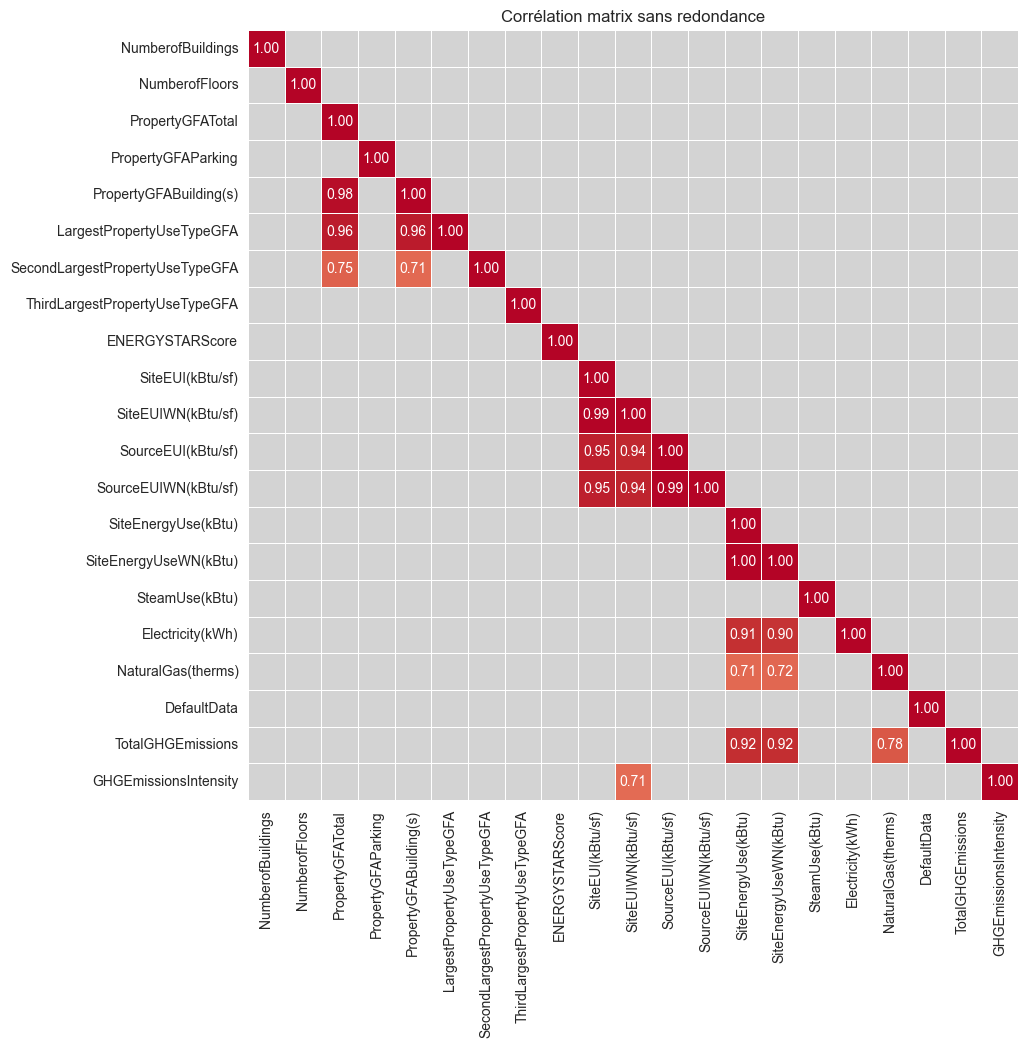

<Figure size 1200x1000 with 0 Axes>

In [535]:
# Colonnes à exclure explicitement
cols_to_exclude = ["YearBuilt","has_energy_score", "Latitude", "Longitude"]
df_numeric = df_non_residential.select_dtypes(include=["int64","float64"])
df_numeric = df_numeric.drop(columns=cols_to_exclude)
excluded_cols = list(set(df_non_residential) - set(df_numeric.columns))
print_md(f"**Colonnes excluses :** {excluded_cols}")
plot_correlation_triangle(df_numeric, method="pearson", threshold=0.7)
plt.show()

In [536]:
# Features corrélées de plus de 90%
df_corr = get_highly_correlated_features(
                df_numeric,
                return_pairs=True,
                threshold=0.90,
                verbose=False,
                round_digits=2,
                return_df=True
            ) 
df_corr

,Feature_1,Feature_2,Correlation
0,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),1.000
1,SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),0.990
2,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),0.990
3,PropertyGFATotal,PropertyGFABuilding(s),0.980
4,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,0.960
5,PropertyGFATotal,LargestPropertyUseTypeGFA,0.960
6,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),0.950
7,SiteEUI(kBtu/sf),SourceEUIWN(kBtu/sf),0.950
8,SiteEUIWN(kBtu/sf),SourceEUIWN(kBtu/sf),0.940
9,SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),0.940


#### 1.8.5. Analyse de cohérence de données

Une étape de validation cruciale consiste à vérifier si les variables respectent les relations physiques qui les lient. Le schéma ci-dessous illustre les formules qui seront testées :
```text
 [Electricity] ───┐
 [NaturalGas]  ───┼──→ [SiteEnergyUse] ──┬──→ [SiteEUI]
 [SteamUse]    ───┘                      │
                                         │
 [PropertyGFABuilding(s)] ───────────────┘
```

In [537]:
zero_gfa_building = df_non_residential["PropertyGFABuilding(s)"].eq(0).sum()
zero_gfa_use = df_non_residential["LargestPropertyUseTypeGFA"].eq(0).sum()
print(f"Zéro count  in PropertyGFABuilding(s) : {zero_gfa_building}")
print(f"Zéro count  in LargestPropertyUseTypeGFA : {zero_gfa_use}")

Zéro count  in PropertyGFABuilding(s) : 0
Zéro count  in LargestPropertyUseTypeGFA : 0


In [538]:
formulas = {
    "GFATotal = GFABuildings + GFAParking": "`PropertyGFATotal` = `PropertyGFABuilding(s)` + `PropertyGFAParking`",
    "SiteEnergyUse(kBtu)": "`SiteEnergyUse(kBtu)` = (`Electricity(kWh)` * 3.412) + (`NaturalGas(therms)` * 100) + `SteamUse(kBtu)`",
}
df_results, df_inconsistencies = check_formula_consistency(
        df_non_residential,
        formulas = formulas,
        rtol = 1e-2,
        atol = 1e-2,
        verbose=True,
        return_df=True,
)


✅ [GFATotal = GFABuildings + GFAParking]
│   ├─ Cible : PropertyGFATotal
│   ├─ Cohérence : 100.00%	| Diff. relative :   0.00%
│   ├─ Diff. moyenne :   0.0000	| Max diff :     0.0000
│   └─ Lignes valides :  1554	| Incohérentes :     0

⚠️ [SiteEnergyUse(kBtu)]
│   ├─ Cible : SiteEnergyUse(kBtu)
│   ├─ Cohérence :  98.71%	| Diff. relative :   0.93%
│   ├─ Diff. moyenne : 51752.4329	| Max diff : 22553694.5380
│   └─ Lignes valides :  1554	| Incohérentes :    20


In [539]:
# Identifier les incohérences pour la colonne : SiteEnergyUse(kBtu)
mask = df_inconsistencies["formula_name"] == "SiteEnergyUse(kBtu)"
assert mask.sum() == 20, f"Il devrait y avoir 20 lignes incohérentes, mais {mask.sum()} ont été trouvées."

# 🏷️ Ajouter une colonne d’indicateur booléen dans le DataFrame original
bad_rows = df_inconsistencies.loc[mask, "row_index"]
df_non_residential["inconsistent_energy_use"] = df_non_residential.index.isin(bad_rows)

In [540]:
formulas = {
    "PropertyGFABuilding(s)" : "`PropertyGFABuilding(s)` = (`LargestPropertyUseTypeGFA` + `SecondLargestPropertyUseTypeGFA` + `ThirdLargestPropertyUseTypeGFA`)",
    "SiteEUI with GFA Buildings" : "`SiteEUI(kBtu/sf)` = `SiteEnergyUse(kBtu)` / `PropertyGFABuilding(s)`",    
    "SiteEUI with property usage GFA" : "`SiteEUI(kBtu/sf)` = `SiteEnergyUse(kBtu)` / (`LargestPropertyUseTypeGFA` + `SecondLargestPropertyUseTypeGFA` + `ThirdLargestPropertyUseTypeGFA`)"

}
_ = check_formula_consistency(
        df_non_residential,
        formulas = formulas,
        rtol = 1e-2,
        atol = 1e-2,
        verbose=True,
        return_df=False,
)


❌ [PropertyGFABuilding(s)]
│   ├─ Cible : PropertyGFABuilding(s)
│   ├─ Cohérence :  47.94%	| Diff. relative :  11.85%
│   ├─ Diff. moyenne : 20023.3904	| Max diff : 1361871.0000
│   └─ Lignes valides :  1554	| Incohérentes :   809

⚠️ [SiteEUI with GFA Buildings]
│   ├─ Cible : SiteEUI(kBtu/sf)
│   ├─ Cohérence :  54.12%	| Diff. relative :   9.09%
│   ├─ Diff. moyenne :   8.9914	| Max diff :  3003.7321
│   └─ Lignes valides :  1554	| Incohérentes :   713

⚠️ [SiteEUI with property usage GFA]
│   ├─ Cible : SiteEUI(kBtu/sf)
│   ├─ Cohérence :  75.93%	| Diff. relative :   9.77%
│   ├─ Diff. moyenne :   5.3529	| Max diff :   326.2684
│   └─ Lignes valides :  1554	| Incohérentes :   374


**Synthèse des Résultats de l'Audit :**
 *   ✅ **`PropertyGFATotal` :** Cohérence de **100%**. La colonne est confirmée comme redondante.
 *   ✅ **`SiteEnergyUse(kBtu)` :** Cohérence de **98.7%**. La colonne est considérée comme fiable. Les 20 incohérences sont flaggées pour analyse.
 *   ❌ **`PropertyGFABuilding(s)` vs `...GFA` :** Cohérence de **47.9%**. Les colonnes de surface par usage (`...GFA`) ne sont pas fiables.
 *   ❌ **`SiteEUI(kBtu/sf)` :** Cohérence de **54.1%**. Cette colonne est massivement incohérente avec sa formule de base et ne peut pas être utilisée en l'état.

### 1.9. Sélection Finale des Features (Pré-Modélisation)

En conclusion de l'analyse, une dernière phase de nettoyage est opérée pour ne conserver que les features les plus robustes. Cette étape inclut l'extraction d'informations structurelles avant de supprimer définitivement les colonnes jugées non pertinentes pour cause de **redondance**, de **manque de fiabilité**, de **fuite de données** ou par **stratégie MVP**.

#### 1.9.1. Extraction des "Flags" Énergétiques
Avant la suppression des colonnes de consommation par source (qui causeraient du **data leakage**), une information structurelle est extraite : la **présence** (`1`/`0`) de chaque source d'énergie.

In [541]:
# Créer un indicateur pour chaque type d'énergie basé sur une consommation supérieure à 0
df_non_residential['uses_steam'] = (df_non_residential['SteamUse(kBtu)'] > 0).astype(int)
df_non_residential['uses_electricity'] = (df_non_residential['Electricity(kWh)'] > 0).astype(int)
df_non_residential['uses_natural_gas'] = (df_non_residential['NaturalGas(therms)'] > 0).astype(int)


print("✅ Flags énergétiques créés.")
display(df_non_residential[['uses_steam', 'uses_electricity', 'uses_natural_gas']].head())

✅ Flags énergétiques créés.


,uses_steam,uses_electricity,uses_natural_gas
0,1,1,1
1,0,1,1
2,1,1,1
3,1,1,1
4,0,1,1


 #### 1.9.2. Suppression des Colonnes Non Pertinentes

En s'appuyant sur les conclusions de l'audit de données, les colonnes suivantes sont maintenant supprimées pour garantir un jeu de features final propre, sans redondance ni fuite de données.

 *   🗑️ **Redondance & Manque de Fiabilité**
     *   **Preuve :** L'analyse par formules a prouvé la redondance de certaines colonnes (`PropertyGFATotal` à **100%**) et les **graves incohérences** d'autres (`SiteEUI` à **55%**).
     *   **Action :** Ces colonnes et leurs dérivés (`...GFA`, `...EUIWN`) sont écartés.

 *   💧 **Fuite de Données (Data Leakage)**
     *   **Preuve :** Les consommations par source (`Electricity(kWh)`, etc.) sont des composantes directes de notre cible `SiteEnergyUse(kBtu)`.
     *   **Action :** Ces colonnes, ainsi que les cibles alternatives (`SiteEnergyUseWN`, `GHG...`), sont systématiquement exclues de `X`.

 *   🚀 **Stratégie MVP (Minimum Viable Product)**
     *   **Preuve :** L'analyse a montré que `LargestPropertyUseType` était la feature d'usage la plus fiable.
     *   **Action :** Pour cette première itération, le focus est mis sur l'usage principal. Les colonnes d'usages secondaires (`Second...`, `Third...`) sont écartées.

In [542]:
cols_to_drop = [
    # 1. Colonnes Redondantes (prouvé par corrélation et formules)
    "PropertyGFATotal",                 # 100% cohérent avec : `PropertyGFABuilding(s)` + `PropertyGFAParking`   
    
    # 2. Colonnes non Fiables ou non utilisées pour la V1
    "PrimaryPropertyType",              # Prouvé comme étant moins fiable et informatif que `LargestPropertyUseType`
    "PropertyName",                     # Identifiant unique sans valeur prédictive
    "SecondLargestPropertyUseType",     # Stratégie MVP : Focus sur l'usage principal pour le premier modèle
    "ThirdLargestPropertyUseType",      # Stratégie MVP : Focus sur l'usage principal pour le premier modèle
    "LargestPropertyUseTypeGFA",        # Moins fiable et corrélé (0.98) à la surface totale
    "SecondLargestPropertyUseTypeGFA",  # Données incomplètes et non utilisées dans la V1
    "ThirdLargestPropertyUseTypeGFA",   # Données incomplètes et non utilisées dans la V1

    # 3. Colonnes de Fuite de Données (conséquences de la consommation, pas des causes)
    "SiteEnergyUseWN(kBtu)",            # Version météo-normalisée de la cible 
    "SiteEUI(kBtu/sf)",                 # Ratio calculé à partir de la cible. Prouvé comme très incohérent (cohérence de 55%).
    "SiteEUIWN(kBtu/sf)",               # Version normalisée du précédent
    "SourceEUI(kBtu/sf)",               # Autre type de ratio, également une fuite de données
    "SourceEUIWN(kBtu/sf)",             # Version normalisée
    "Electricity(kWh)",                 # Composante directe de la cible `SiteEnergyUse(kBtu)`
    "NaturalGas(therms)",               # Composante directe de la cible `SiteEnergyUse(kBtu)`
    "SteamUse(kBtu)",                   # Composante directe de la cible `SiteEnergyUse(kBtu)`
    "GHGEmissionsIntensity",            # Ratio calculé à partir de `TotalGHGEmissions`, une autre cible potentielle
]

In [543]:
with cols_decrease("df_non_residential"):
    df_non_residential = df_non_residential.drop(columns=cols_to_drop)

✅ df_non_residential: (1554, 41) → (1554, 24)
   ➕ Added columns: None
   ➖ Removed columns: SiteEUI(kBtu/sf), PropertyGFATotal, GHGEmissionsIntensity, PrimaryPropertyType, SteamUse(kBtu), Electricity(kWh), PropertyName, LargestPropertyUseTypeGFA, ThirdLargestPropertyUseType, ThirdLargestPropertyUseTypeGFA, SiteEnergyUseWN(kBtu), SourceEUIWN(kBtu/sf), NaturalGas(therms), SecondLargestPropertyUseType, SecondLargestPropertyUseTypeGFA, SiteEUIWN(kBtu/sf), SourceEUI(kBtu/sf)
   ↔️  Rows unchanged


In [544]:
df_non_residential.columns

Index(['BuildingType', 'ZipCode', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'ENERGYSTARScore', 'SiteEnergyUse(kBtu)', 'DefaultData',
       'ComplianceStatus', 'TotalGHGEmissions', 'c_ListOfAllPropertyUseTypes',
       'has_energy_score', 'inconsistent_energy_use', 'uses_steam',
       'uses_electricity', 'uses_natural_gas'],
      dtype='object')

### 1.10. Mettre à jour les groups de de noms de colonnes

In [545]:
location_features = get_existing_columns(df_non_residential, location_features)
print_md(f"**location_features:**{location_features}")

structural_features = get_existing_columns(df_non_residential, structural_features)
print_md(f"**structural_features:**{structural_features}")

usage_features = get_existing_columns(df_non_residential, usage_features)
print_md(f"**usage_features:**{usage_features}")

rating_features= get_existing_columns(df_non_residential, rating_features)
print_md(f"**rating_features:**{rating_features}")

target_and_leaks = get_existing_columns(df_non_residential, target_and_leaks)
print_md(f"**target_and_leaks:**{target_and_leaks}")

**location_features:**['CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'ZipCode']

**structural_features:**['YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking', 'PropertyGFABuilding(s)']

**usage_features:**['BuildingType', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType']

**rating_features:**['ENERGYSTARScore', 'DefaultData', 'ComplianceStatus']

**target_and_leaks:**['SiteEnergyUse(kBtu)', 'TotalGHGEmissions']

In [546]:
engineered_features = [
    "has_energy_score",
    "c_ListOfAllPropertyUseTypes",
    "uses_steam",
    "uses_electricity",
    "uses_natural_gas",
]

In [547]:
# Liste de colonnes non groupées
grouped_cols = location_features + structural_features + usage_features + rating_features + target_and_leaks + engineered_features
print_md( "**Colonnes non groupées :**",
    [col for col in df_non_residential if col not in grouped_cols] 
)

**Colonnes non groupées :**

['inconsistent_energy_use']

In [548]:
missing_summary(df_non_residential)

,col,missing_count,missing_pct
0,ZipCode,16,1.030


## 2. Modélisation

### 2.1. Import des Modules de Modélisation

In [549]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

import bentoml
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
import joblib, os

from sklearn.preprocessing import FunctionTransformer

### 2.2. Feature Engineering

 Pour enrichir le jeu de données, deux nouvelles features sont créées afin de capturer des informations structurelles qui étaient implicites :

 1.  **`number_of_uses` :** Le nombre total d'usages d'un bâtiment.
     *   *Hypothèse :* La **complexité d'usage** est un indicateur de la complexité énergétique.
 2.  **`has_parking` :** Un drapeau binaire (`1`/`0`) indiquant la présence d'un parking.
     *   *Hypothèse :* La présence d'un parking (éclairage, ventilation...) a un **impact énergétique distinct**.

#### 2.2.1. Création de la feature 'number_of_uses'

In [550]:
# On calcule simplement la longueur de chaque liste dans la colonne 'c_ListOfAllPropertyUseTypes'.
# Si la liste est vide (NaN), on considère qu'il y a 1 usage (le principal).
df_non_residential['number_of_uses'] = df_non_residential['c_ListOfAllPropertyUseTypes'].apply(
    lambda x: len(x) if isinstance(x, list) else 1
).astype(int)
engineered_features.append("number_of_uses")

print("✅ Feature 'number_of_uses' créée.")

✅ Feature 'number_of_uses' créée.


In [551]:
df_non_residential['number_of_uses'].value_counts(dropna=False)

number_of_uses
1     754
2     477
3     187
4      75
5      37
6      16
9       3
7       3
11      1
8       1
Name: count, dtype: int64

#### 2.2.2. Création de la feature 'has_parking'

In [552]:
df_non_residential['has_parking'] = (df_non_residential['PropertyGFAParking'] > 0).astype(int)
engineered_features.append("has_parking")

print("✅ Feature 'has_parking' créée.")

✅ Feature 'has_parking' créée.


#### 2.2.3. Nettoyage final des colonnes d'usage

In [553]:
# Maintenant que nous avons extrait l'information utile de 'ListOfAllPropertyUseTypes'
# et de sa version en liste 'c_ListOfAllPropertyUseTypes', nous pouvons les supprimer.
# Cela évite la redondance et simplifie le jeu de données pour la modélisation.
colummns_to_drop = ['ListOfAllPropertyUseTypes', 'c_ListOfAllPropertyUseTypes']

shape_before = df_non_residential.shape
df_final_features = df_non_residential.drop(columns=colummns_to_drop)
report_shape_changes(shape_before, df_final_features.shape)
engineered_features.remove("c_ListOfAllPropertyUseTypes")

print(f"✅ Colonnes {colummns_to_drop} supprimées.")
print_md("**-- Aperçu des nouvelles features créées ---**")
df_final_features[['LargestPropertyUseType'] + engineered_features].head()

Shape avant: (1554, 26)
Shape après: (1554, 24)
  🗑️  Colonnes supprimées: 2
✅ Colonnes ['ListOfAllPropertyUseTypes', 'c_ListOfAllPropertyUseTypes'] supprimées.


**-- Aperçu des nouvelles features créées ---**

,LargestPropertyUseType,has_energy_score,uses_steam,uses_electricity,uses_natural_gas,number_of_uses,has_parking
0,Hotel,1,1,1,1,1,0
1,Hotel,1,0,1,1,3,1
2,Hotel,1,1,1,1,1,1
3,Hotel,1,1,1,1,1,0
4,Hotel,1,0,1,1,3,1


### 2.3. Préparation des Features pour la Modélisation

In [554]:
df_final_features.columns

Index(['BuildingType', 'ZipCode', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'ENERGYSTARScore', 'SiteEnergyUse(kBtu)',
       'DefaultData', 'ComplianceStatus', 'TotalGHGEmissions',
       'has_energy_score', 'inconsistent_energy_use', 'uses_steam',
       'uses_electricity', 'uses_natural_gas', 'number_of_uses',
       'has_parking'],
      dtype='object')

#### 2.3.1 : Analyse des outliers sur la variable cible
L’analyse de la distribution de `SiteEnergyUse(kBtu)` a révélé une **asymétrie marquée**, avec quelques bâtiments affichant des consommations d’énergie **disproportionnées**.  
Des valeurs extrêmes similaires apparaissent également dans les features de surface (`PropertyGFABuilding(s)` et `PropertyGFAParking`).

* **Problème :** Supprimer les outliers de chaque colonne séparément entraînerait une perte de données excessive.  
* **Stratégie :** Une approche **consolidée** a été adoptée : un **masque unique** identifie les lignes considérées comme outliers dans **au moins une** des trois colonnes, selon un seuil défini par le paramètre `Q_THRESHOLD` (0.99 par défaut).  
* **Action & Impact :** Cette méthode supprime seulement **38 lignes**, contre **48** avec la méthode classique, tout en améliorant la distribution et la robustesse du modèle.

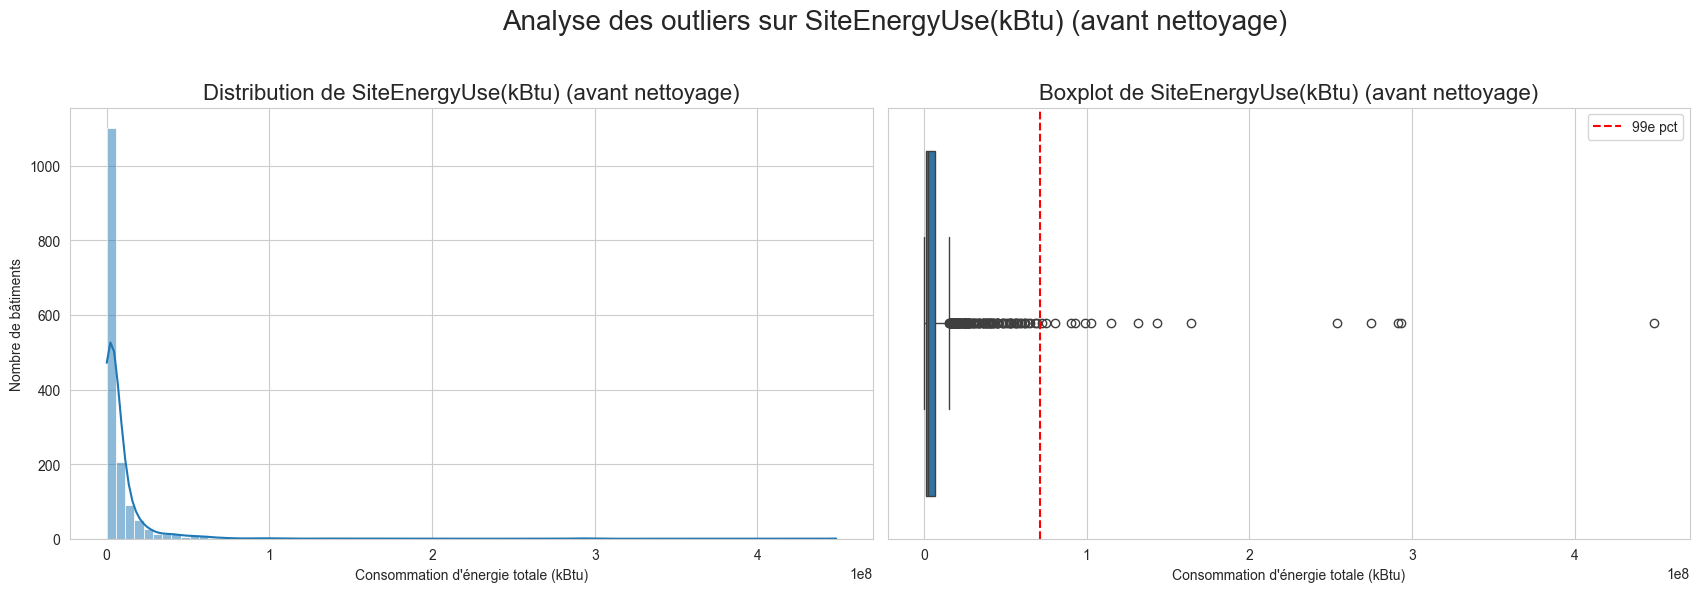

**--- Statistiques descriptives de la cible ---**

count         1,554.000
mean      7,943,837.979
std      22,044,200.232
min          16,808.900
25%       1,236,149.500
50%       2,552,392.875
75%       6,913,348.500
max     448,385,312.000
Name: SiteEnergyUse(kBtu), dtype: float64

In [555]:
def plot_target_distribution(df, title_suffix="", q=None):
    _, axes = plt.subplots(1, 2, figsize=(18, 6))

    if q:
        q_value = df[TARGET_COL].quantile(q)

    # --- Histogramme + densité ---
    sns.histplot(data=df, x=TARGET_COL, kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution de {TARGET_COL} {title_suffix}", fontsize=16)
    axes[0].set_xlabel("Consommation d'énergie totale (kBtu)")
    axes[0].set_ylabel("Nombre de bâtiments")

    # --- Boxplot ---
    sns.boxplot(data=df, x=TARGET_COL, ax=axes[1])
    if q:
        axes[1].axvline(q_value, color="red", linestyle="--", label=f"{q*100:.0f}e pct")
        axes[1].legend()
    
    axes[1].set_title(f"Boxplot de {TARGET_COL} {title_suffix}", fontsize=16)
    axes[1].set_xlabel("Consommation d'énergie totale (kBtu)")    

    plt.suptitle(f"Analyse des outliers sur {TARGET_COL} {title_suffix}", fontsize=20)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    
    plt.show()

plot_target_distribution(df_final_features,  title_suffix="(avant nettoyage)", q=Q_THRESHOLD)

# Afficher les statistiques descriptives pour avoir les chiffres exacts
print_md("**--- Statistiques descriptives de la cible ---**")
display(df_final_features[TARGET_COL].describe())

#### 2.3.2 : Suppression des outliers de la variable cible

**SiteEnergyUse(kBtu) (99e percentile):** 70_961_399.52

**PropertyGFABuilding(s) (99e percentile):** 869_832.06

**PropertyGFAParking (99e percentile):** 203_369.93

Nombre de bâtiments considérés comme outliers: 38

Shape avant: (1554, 24)
Shape après: (1516, 24)
  ✂️  Lignes supprimées: 38


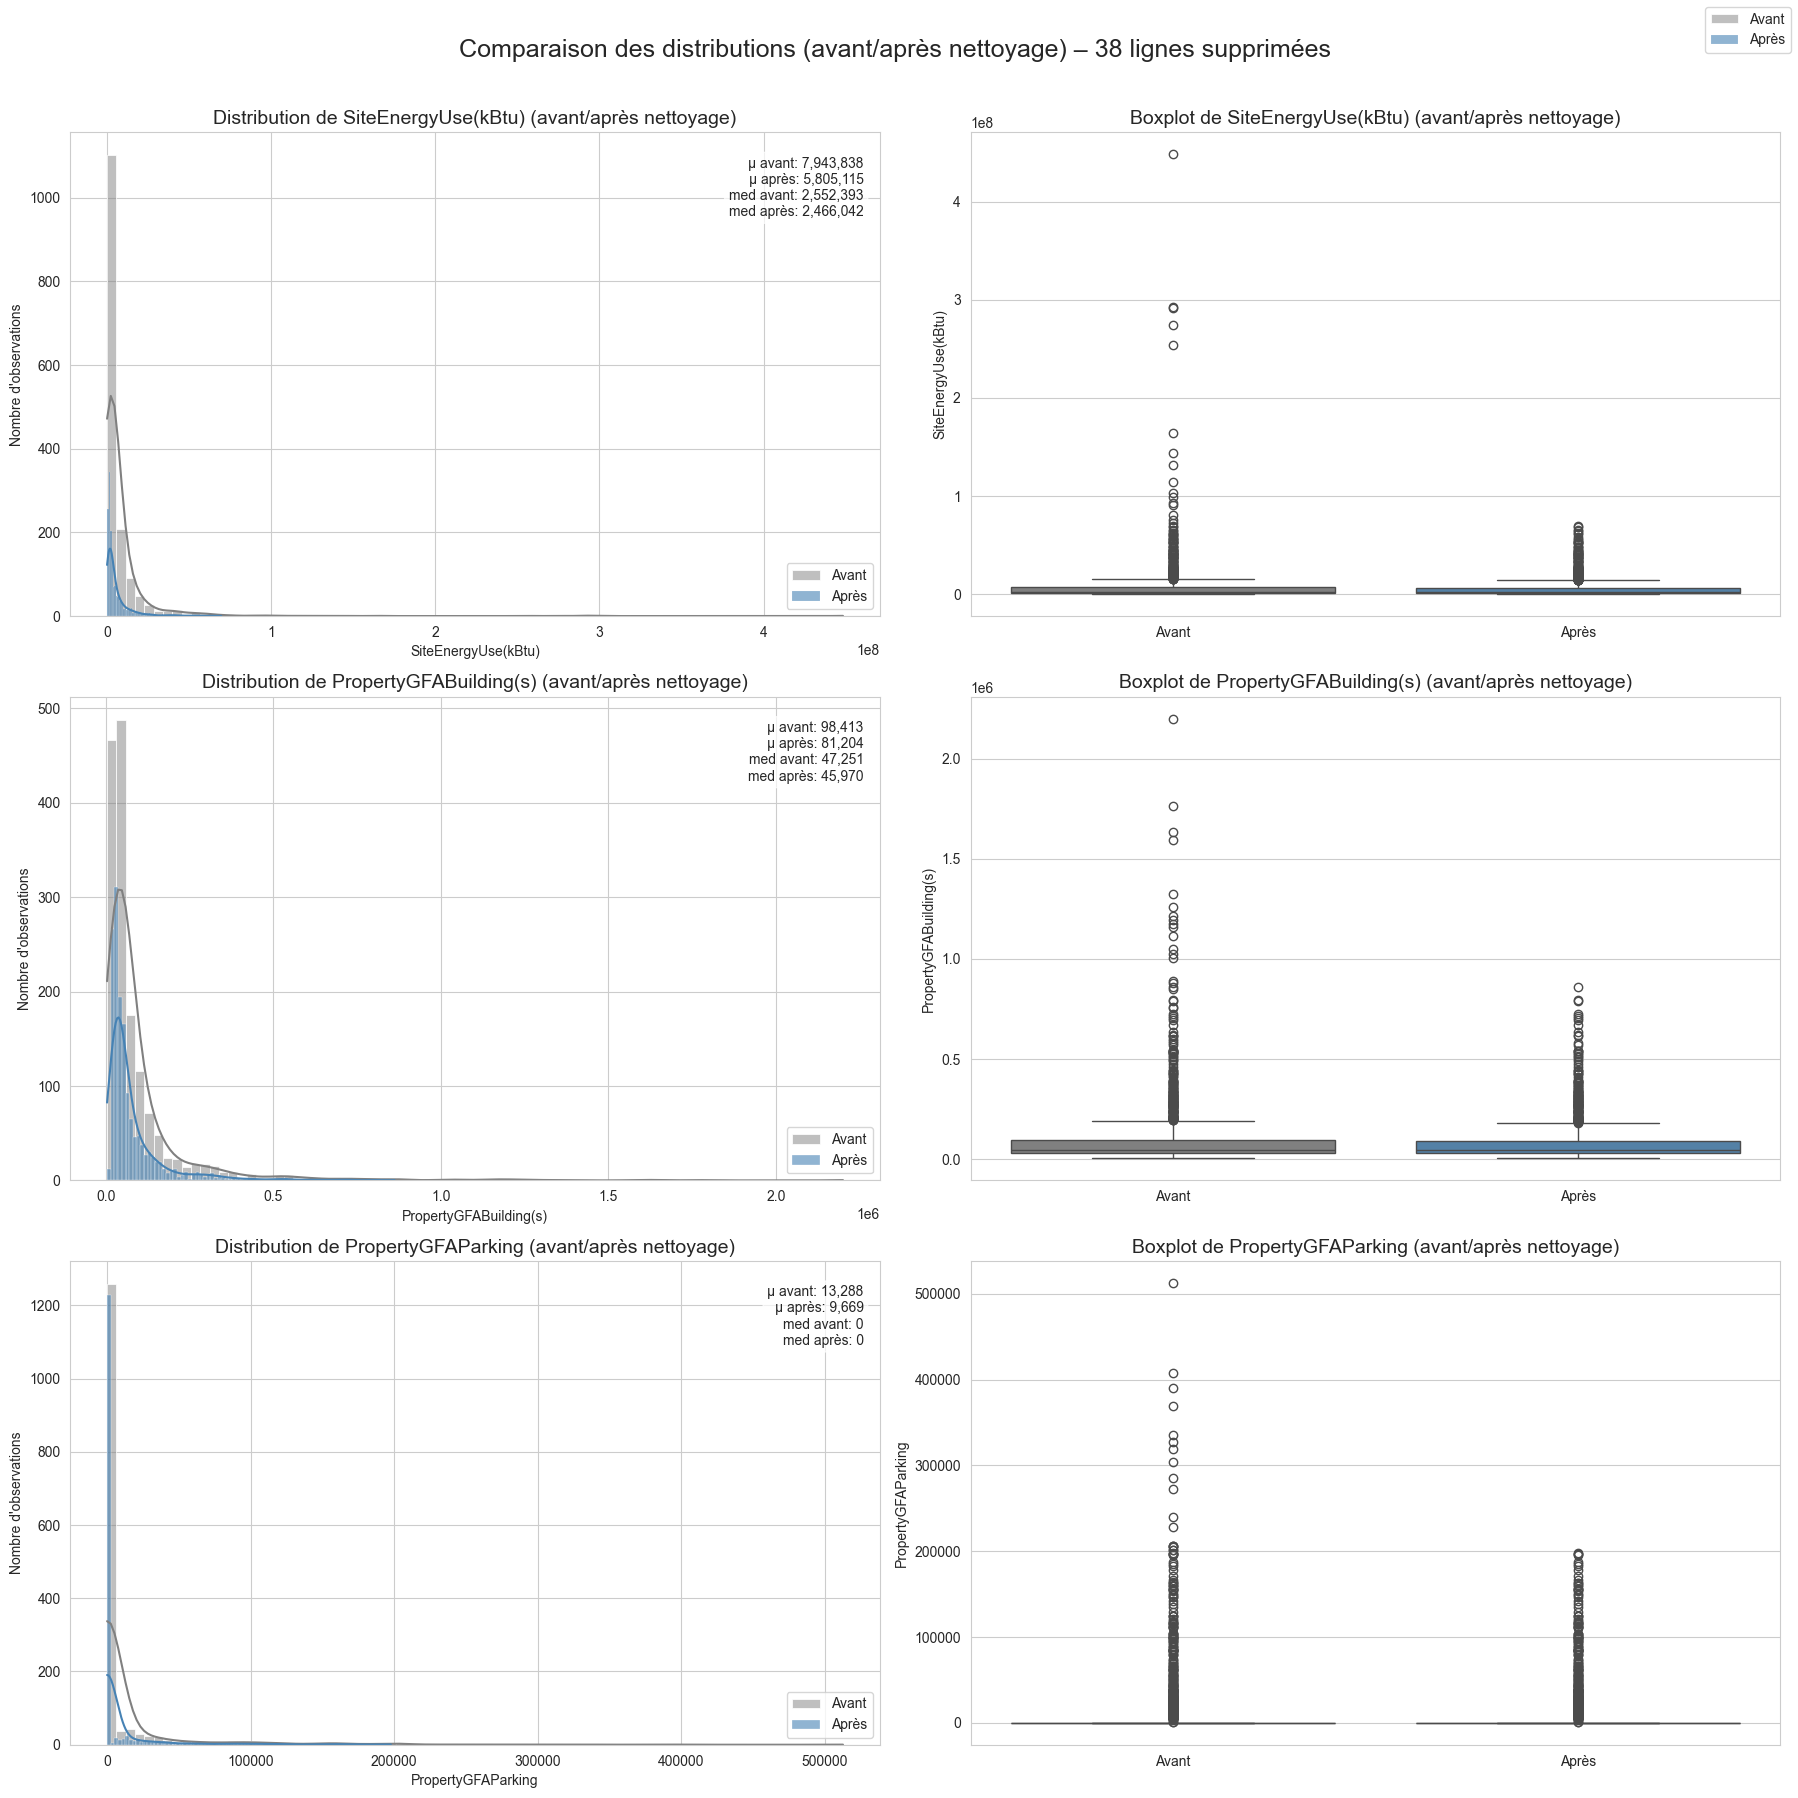

In [556]:
# Calculer le seuil au qᵉ percentile

cols_to_check = [TARGET_COL, "PropertyGFABuilding(s)", "PropertyGFAParking"]

assert df_final_features.shape[0] > 0, "df_final_features est vide!!"
ol_thresholds = {col: df_final_features[col].quantile(q=Q_THRESHOLD) for col in cols_to_check}

for col in cols_to_check:
    print_md(f"**{col} ({Q_THRESHOLD*100:.0f}e percentile):** {ol_thresholds[col]:_.2f}")

outlier_mask = pd.Series(False, index=df_final_features.index)
for col in cols_to_check:
    outlier_mask |= (df_final_features[col] > ol_thresholds[col]) 

n_outliers = outlier_mask.sum()
outlier_pct = n_outliers / df_final_features.shape[0]
assert (outlier_pct) < 0.1, f"More than 10% of the data will be deleted, actually: {outlier_pct*100:.2f}, please verify your Q_THRESHOLD values"
print_md(f"Nombre de bâtiments considérés comme outliers: {n_outliers}")

shape_before = df_final_features.shape
df_no_outliers = df_final_features.loc[~outlier_mask].copy()
report_shape_changes(shape_before, df_no_outliers.shape)
assert n_outliers == shape_before[0] - df_no_outliers.shape[0], "Nombre de lignes supprimées n'est pas cohérent"

helper.plot_target_distribution_comparison(
    df_before = df_final_features,
    df_after = df_no_outliers,
    cols = cols_to_check    
)
plt.show()

#### 2.3.3 : Sélection Finale des Features & Préparation de (X) et (y)

En conclusion de l'analyse, un dernier filtrage est opéré pour constituer les jeux de données `X` (features) et `y` (cible) finaux.
 Les colonnes suivantes sont **intentionnellement exclues** du jeu de features `X` :
 *   🎯 **Cibles et Fuites de Données (Data Leakage) :**
     *   `SiteEnergyUse(kBtu)` : Définie comme notre **variable cible `y`**.
     *   `TotalGHGEmissions` : Cible alternative fortement corrélée à la consommation. Son inclusion constituerait une **fuite de données**.
 *   🗺️ **Features Géographiques Redondantes :**
     *   `Latitude`, `Longitude`, `ZipCode` : Ces features sont **redondantes** avec `Neighborhood` et `CouncilDistrictCode`, qui représentent la localisation à une échelle plus appropriée pour le modèle. Conserver les coordonnées fines augmenterait le risque de **sur-apprentissage (overfitting)**.
 *   🛠️ **Colonnes "Helper" :**
     *   `inconsistent_energy_use` : Ce drapeau, créé durant l'analyse, n'a plus d'utilité pour la modélisation.

In [557]:
# Créer la série cible "y"
y = df_no_outliers[TARGET_COL]

# Créer le DataFrame X

# On supprime les cibles et les colonnes jugées inutiles ou redondantes
cols_to_drop = [
                'SiteEnergyUse(kBtu)', 
                'TotalGHGEmissions',
                'Latitude',
                'Longitude',
                'ZipCode',
                'inconsistent_energy_use',
]

shape_before = df_no_outliers.shape
X = df_no_outliers.drop(columns=cols_to_drop)
report_shape_changes(shape_before, X.shape)

Shape avant: (1516, 24)
Shape après: (1516, 18)
  🗑️  Colonnes supprimées: 6


#### 2.3.4. Séparation des Données

 Pour évaluer la performance de nos futurs modèles sur des données inconnues, le jeu de données est maintenant séparé en deux ensembles distincts :

 *   **Ensemble d'Entraînement (`_train`) :** **80%** des données, utilisé pour l'apprentissage du modèle.
 *   **Ensemble de Test (`_test`) :** **20%** des données, mis de côté et utilisé **uniquement** pour l'évaluation finale de la performance.

 La séparation est effectuée avec un `random_state` fixe pour garantir la **reproductibilité** de nos expérimentations.

In [558]:
assert X.shape[0] == y.shape[0], "❌ Les tailles de X et y ne sont pas identiques!!"
assert y.name == TARGET_COL, "❌ La cible est changée !! "
X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE, 
        random_state=RANDOM_STATE
)

print("✅ Données séparées en ensembles d'entraînement et de test.")
print_md(f"**Shape de X_train :** {X_train.shape}")
print_md(f"**Shape de X_test :** {X_test.shape}")

cols_to_display = [col for col in X.columns.tolist()]
print_md(f"**Colonnes X:** {cols_to_display}")
print_md(f"**Colonne cible:** {y.name}")

✅ Données séparées en ensembles d'entraînement et de test.


**Shape de X_train :** (1212, 18)

**Shape de X_test :** (304, 18)

**Colonnes X:** ['BuildingType', 'CouncilDistrictCode', 'Neighborhood', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseType', 'ENERGYSTARScore', 'DefaultData', 'ComplianceStatus', 'has_energy_score', 'uses_steam', 'uses_electricity', 'uses_natural_gas', 'number_of_uses', 'has_parking']

**Colonne cible:** SiteEnergyUse(kBtu)

#### 2.3.5 : Encodage des Variables Catégorielles : Une Approche Itérative
Pour que les modèles puissent utiliser les variables textuelles, celles-ci doivent être converties en format numérique. Une démarche itérative a été adoptée.

In [559]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns.to_list()
categorical_features = X.select_dtypes(include='object').columns.to_list()

missing_cols =  set(X.columns) - (set(categorical_features).union(numeric_features))
assert not missing_cols, f"❌ Colonnes suivantes manquantes dans la classification : {missing_cols}"
print("✅ Toutes les colonnes ont été correctement classées.")

✅ Toutes les colonnes ont été correctement classées.


In [560]:
print_md(f"**Colonnes catégorielles:** {categorical_features}")
print_md(f"**Colonnes numériques:** {numeric_features}")

**Colonnes catégorielles:** ['BuildingType', 'CouncilDistrictCode', 'Neighborhood', 'LargestPropertyUseType', 'ComplianceStatus']

**Colonnes numériques:** ['YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ENERGYSTARScore', 'DefaultData', 'has_energy_score', 'uses_steam', 'uses_electricity', 'uses_natural_gas', 'number_of_uses', 'has_parking']

##### 2.3.5.1. Expérience 1 : Encodage One-Hot Standard
 Une première approche consiste à appliquer un `OneHotEncoder` standard à toutes les variables catégorielles (`BuildingType`, `Neighborhood`, etc.).

In [561]:
encoder_demo_1 = ColumnTransformer(
            transformers=[
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
            ],
            remainder='passthrough' # Garde toutes les autres colonnes
)
encoder_demo_1.set_output(transform="pandas")

X_encoded_1 = encoder_demo_1.fit_transform(X)

display(X_encoded_1.head())
report_shape_changes(X.shape, X_encoded_1.shape)

created = X_encoded_1.shape[1] - X.shape[1] + len(categorical_features)
removed = len(categorical_features)
print_md(
    f"✅ **Encodage terminé :** {created} nouvelle(s) feature(s) générée(s) , "
    f"  \n{removed} feature(s) source supprimée(s)."
)

,cat__BuildingType_Campus,cat__BuildingType_NonResidential,cat__BuildingType_Nonresidential COS,cat__BuildingType_Nonresidential WA,cat__BuildingType_SPS-District K-12,cat__CouncilDistrictCode_1,cat__CouncilDistrictCode_2,cat__CouncilDistrictCode_3,cat__CouncilDistrictCode_4,cat__CouncilDistrictCode_5,...,remainder__PropertyGFAParking,remainder__PropertyGFABuilding(s),remainder__ENERGYSTARScore,remainder__DefaultData,remainder__has_energy_score,remainder__uses_steam,remainder__uses_electricity,remainder__uses_natural_gas,remainder__number_of_uses,remainder__has_parking
0,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,88434,60.000,0,1,1,1,1,1,0
1,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,15064,88502,61.000,0,1,0,1,1,3,1
3,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,61320,56.000,0,1,1,1,1,1,0
4,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,62000,113580,75.000,0,1,0,1,1,3,1
5,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,37198,60090,74.000,0,0,0,1,1,1,1


Shape avant: (1516, 18)
Shape après: (1516, 92)
  📊 Colonnes ajoutées: 74


✅ **Encodage terminé :** 79 nouvelle(s) feature(s) générée(s) ,   
5 feature(s) source supprimée(s).

##### 2.3.5.2. Analyse de Sparsité & Identification d'un Problème
 L'analyse de ces nouvelles features révèle un problème majeur : la **haute sparsité**.

In [562]:
# Isoler les colonnes encodées
encoded_columns = [col for col in X_encoded_1.columns if col.startswith("cat__")]
 
# Garde-fou
assert len(encoded_columns) == created, f"Incohérence: {len(encoded_columns)} colonnes encodées, attendu {created}"
print(f"Vérification cohérente : {len(encoded_columns)} colonnes encodées comme attendu ✅")

# Calculer le pourcentage de zéros pour chacune de ces colonnes
sparsity_report = helper.get_sparsity_report(X_encoded_1[encoded_columns], round_digits=3)
sparsity_report
print_md(        
    "**Rapport de parcimonie**",
    sparsity_report.head(15)      
)

Vérification cohérente : 79 colonnes encodées comme attendu ✅


**Rapport de parcimonie**

,features,zero_rate
0,cat__BuildingType_Nonresidential WA,99.934
1,cat__LargestPropertyUseType_Police Station,99.934
2,cat__LargestPropertyUseType_Movie Theater,99.934
3,cat__LargestPropertyUseType_Fire Station,99.934
4,cat__LargestPropertyUseType_Lifestyle Center,99.934
5,cat__LargestPropertyUseType_Courthouse,99.934
6,cat__Neighborhood_Delridge Neighborhoods,99.934
7,cat__LargestPropertyUseType_Pre-school/Daycare,99.934
8,cat__LargestPropertyUseType_Personal Services ...,99.934
9,cat__LargestPropertyUseType_Data Center,99.868


 **Insight Clé :** 
 - **30 features** créées sont **remplies à plus de 99.5% par des zéros**. 
 - Ces colonnes, issues de catégories très rares, risquent d'ajouter du bruit et de la complexité inutile, augmentant le risque de sur-apprentissage.
 - Cette découverte **motive une seconde approche** plus robuste pour gérer ces catégories rares.

In [563]:
threshold = 99.5  # seuil du taux de zéros
print_md(
    f'**{(sparsity_report["zero_rate"] > threshold).sum()}** catégorie(s) apparaissent moins de **{100 - threshold:.1f}%** des cas'
)

**30** catégorie(s) apparaissent moins de **0.5%** des cas

##### 2.3.5.3. Expérience 2 : Encodage Robuste avec Regroupement des Catégories Rares
 **Stratégie Adoptée :**
 *   **`min_frequency=MIN_FREQ_THRESHOLD` :** Pour améliorer la généralisation du modèle, les catégories apparaissant moins de **10 fois** (`MIN_FREQ_THRESHOLD`) sont automatiquement regroupées en une seule catégorie "infrequent". Ce seuil est configurable pour permettre des expérimentations futures.
 *   **`drop=None` :** La suppression d'une colonne par feature (`drop='first'`) est **intentionnellement désactivée** (Voir 2.4.1)

 
 **Résultat :** Le nombre de features encodées est réduit de **79 à 50**. Le modèle final sera plus simple et se concentrera sur les catégories statistiquement les plus significatives.
 **Cette approche robuste sera celle retenue pour le pipeline de modélisation final.**

In [564]:
encoder_demo_2 = ColumnTransformer(
            transformers=[
                ('cat', OneHotEncoder(
                    handle_unknown='ignore',                            # Ignore les catégories inconnues lors de la prédiction
                    sparse_output=False,                                # Retourne un array dense 
                    min_frequency=MIN_FREQ_THRESHOLD,                   # Regroupe les catégories apparaissant moins de X fois en une seule
                    drop = 'first' if OH_ENCODER_DROP_FIRST else None   # Supprime une colonne par feature pour éviter la multicolinéarité                    
                ), categorical_features)
            ],
            remainder='passthrough',                                    # Garde toutes les autres colonnes
)
encoder_demo_2.set_output(transform="pandas")

X_encoded_2 = encoder_demo_2.fit_transform(X)
X_encoded_2 = X_encoded_2.rename(columns=lambda c: re.sub(r"^remainder__", "", c))

display(X_encoded_2.head())
report_shape_changes(X.shape, X_encoded_2.shape)

created = X_encoded_2.shape[1] - X.shape[1] + len(categorical_features)
removed = len(categorical_features)
print_md(
    f"✅ **Encodage terminé :** {created} nouvelle(s) feature(s) générée(s) , "
    f"  \n{removed} feature(s) source supprimée(s)."
)

,cat__BuildingType_Campus,cat__BuildingType_NonResidential,cat__BuildingType_Nonresidential COS,cat__BuildingType_SPS-District K-12,cat__BuildingType_infrequent_sklearn,cat__CouncilDistrictCode_1,cat__CouncilDistrictCode_2,cat__CouncilDistrictCode_3,cat__CouncilDistrictCode_4,cat__CouncilDistrictCode_5,...,PropertyGFAParking,PropertyGFABuilding(s),ENERGYSTARScore,DefaultData,has_energy_score,uses_steam,uses_electricity,uses_natural_gas,number_of_uses,has_parking
0,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,88434,60.000,0,1,1,1,1,1,0
1,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,15064,88502,61.000,0,1,0,1,1,3,1
3,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0,61320,56.000,0,1,1,1,1,1,0
4,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,62000,113580,75.000,0,1,0,1,1,3,1
5,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,37198,60090,74.000,0,0,0,1,1,1,1


Shape avant: (1516, 18)
Shape après: (1516, 63)
  📊 Colonnes ajoutées: 45


✅ **Encodage terminé :** 50 nouvelle(s) feature(s) générée(s) ,   
5 feature(s) source supprimée(s).

In [565]:
# Isoler les colonnes encodées
encoded_columns = [col for col in X_encoded_2.columns if col.startswith("cat__")]
 
# Garde-fou
assert len(encoded_columns) == created, f"Incohérence: {len(encoded_columns)} colonnes encodées, attendu {created}"
print(f"Vérification cohérente : {len(encoded_columns)} colonnes encodées comme attendu ✅")

# Calculer le pourcentage de zéros pour chacune de ces colonnes
sparsity_report = helper.get_sparsity_report(X_encoded_2[encoded_columns], round_digits=3)
sparsity_report
print_md(        
    "**Rapport de parcimonie**",
    sparsity_report.head(15)      
)

Vérification cohérente : 50 colonnes encodées comme attendu ✅


**Rapport de parcimonie**

,features,zero_rate
0,cat__BuildingType_infrequent_sklearn,99.934
1,cat__Neighborhood_infrequent_sklearn,99.934
2,cat__LargestPropertyUseType_Restaurant,99.274
3,cat__LargestPropertyUseType_Refrigerated Wareh...,99.274
4,cat__LargestPropertyUseType_Laboratory,99.274
5,cat__ComplianceStatus_Missing Data,99.274
6,cat__ComplianceStatus_Non-Compliant,99.077
7,cat__BuildingType_Campus,98.879
8,cat__LargestPropertyUseType_Other - Entertainm...,98.747
9,cat__LargestPropertyUseType_Senior Care Community,98.681


### 2.4. Comparaison de Différents Modèles Supervisés

In [566]:
X.columns

Index(['BuildingType', 'CouncilDistrictCode', 'Neighborhood', 'YearBuilt',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'LargestPropertyUseType', 'ENERGYSTARScore',
       'DefaultData', 'ComplianceStatus', 'has_energy_score', 'uses_steam',
       'uses_electricity', 'uses_natural_gas', 'number_of_uses',
       'has_parking'],
      dtype='object')

#### 2.4.1. Encodage Final des Variables Catégorielles

 Pour évaluer et comparer différents types de modèles, un premier pipeline de pré-traitement est mis en place. 
 
 Il a pour but de transformer les données brutes en un format numérique simple que tous les modèles peuvent utiliser.

  Le `ColumnTransformer` est configuré avec un `OneHotEncoder` pour préparer les features catégorielles. Les paramètres ont été choisis de manière stratégique :

 -   **`min_frequency=10` :** Les catégories rares sont regroupées pour éviter le sur-apprentissage.
 -   **`handle_unknown='ignore'` :** Permet au processus de ne pas échouer si de nouvelles catégories apparaissent.
 -   **`remainder='passthrough'` :** Les colonnes numériques sont conservées telles quelles pour cette première évaluation.
 -   **`drop=None` (Pas de `drop='first'`) :** La suppression d'une colonne pour gérer la multicolinéarité a été **intentionnellement évitée**.
     1.  Le modèle cible, un `RandomForestRegressor`, n'est pas sensible à la multicolinéarité.
     2.  Plus important, combiner `drop='first'` et `handle_unknown='ignore'` crée une ambiguïté, car les catégories inconnues sont encodées de la même manière (une ligne de zéros) que la catégorie de référence supprimée.

In [567]:
ct_encoder = ColumnTransformer(
            transformers=[
                ('cat', OneHotEncoder(
                    handle_unknown='ignore',                            # Ignore les catégories inconnues lors de la prédiction
                    sparse_output=False,                                # Retourne un array dense 
                    min_frequency=MIN_FREQ_THRESHOLD,                   # Regroupe les catégories apparaissant moins de X fois en une seule
                    drop = 'first' if OH_ENCODER_DROP_FIRST else None   # Supprime une colonne par feature pour éviter la multicolinéarité                    
                ), categorical_features)
            ],
            remainder='passthrough',                                    # Garde toutes les autres colonnes
            verbose_feature_names_out = False                           # Ne pas préfixer les noms de colonnes de sortie
)
ct_encoder.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fea

#### 2.4.2. Protocole d'Évaluation

 Pour garantir une comparaison juste et robuste, un protocole d'évaluation standardisé est mis en place :
 -   **Modèles Testés :**
     -   `DummyRegressor` : Notre baseline, qui prédit toujours la moyenne.
     -   `LinearRegression` : Un modèle linéaire simple.
     -   `SVR` (Support Vector Regressor) : Un modèle linéaire plus complexe.
     -   `RandomForestRegressor` : Un modèle d'ensemble non-linéaire (à base d'arbres).
 -   **Pré-traitement Commun :** Chaque modèle est intégré dans un `Pipeline` qui inclut le préprocesseur (`ct_encoder`) défini précédemment, garantissant que tous les modèles reçoivent les mêmes données encodées. Un `StandardScaler` est appliqué pour les modèles linéaires sensibles à l'échelle des features.
 *   **Évaluation Robuste :** La performance de chaque pipeline est mesurée via une **validation croisée à 5 plis (`cross_validate`)**.Nous nous concentrons sur 3 métriques principales :
     -   **R² (Coefficient de Détermination) :** Mesure la proportion de la variance de la cible expliquée par le modèle (plus c'est haut, mieux c'est).
     -   **RMSE (Root Mean Squared Error) :** Mesure l'erreur de prédiction moyenne dans l'unité de la cible (kBtu). Plus c'est bas, mieux c'est.
     -   **MAE (Mean Absolute Error) :** Mesure l'erreur absolue moyenne, moins sensible aux outliers que la RMSE. *Plus c'est bas, mieux c'est.*

In [568]:
print_md(
    f"**X (final):** {X.shape}",
    f"**y (final):** {y.shape}",
)

# Selection des features à mettre à l'échelle (Scaling)
features_to_scale = helper.get_features_to_scale(X)
binary_features = helper.get_binary_features(X)

all_features = categorical_features + binary_features + features_to_scale
assert len(all_features) == len(set(all_features)), "❌ Certaines features sont dupliquées"
assert set(X.columns) == set(all_features), "❌ Les colonnes de X ne correspondent pas"

print_md(f"**Colonnes à mettres à l'échelle :**  {features_to_scale}")

# Mise à l'échelle des colonnes "features_to_scale"
ct_scaler = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), features_to_scale)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

#  Dictionnaire pipeline
models = {
    "Dummy": Pipeline(steps=[
        ('encoder', ct_encoder),
        ('scaler', ct_scaler),        
        ('model', DummyRegressor(strategy="mean"))
    ]),
    "LinearRegression": Pipeline(steps=[
        ('encoder', ct_encoder),
        ('scaler', ct_scaler),        
        ('model', LinearRegression())
    ]),
    "RandomForest": Pipeline(steps=[
        ('encoder', ct_encoder),
        ('model', RandomForestRegressor(random_state=RANDOM_STATE,  n_jobs=-1)) # Pas besoin de scaling
    ]),
    "SVR": Pipeline(steps=[
        ('encoder', ct_encoder),
        ('scaler', ct_scaler),        
        ('model', TransformedTargetRegressor( # On doit aussi scaller la cible sinon le model vas échouer fortement
            regressor=SVR(kernel='rbf', C=10.0, epsilon=0.1),
            transformer=StandardScaler()
        ))        
    ])
}

# Validation croisée
results = []
for name, model in models.items():
    print(f"⌚ Évaluation de {name} ...")

    cv = cross_validate(
        model, X_train, y_train,
        cv=5,
        scoring=["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"],
        return_train_score=True,
        n_jobs=-1
    )

    results.append({
        "model_name": name,
        "test_r2": cv["test_r2"].mean(),
        "train_r2": cv["train_r2"].mean(),
        "std_r2": cv["test_r2"].std(),
        "RMSE": -cv["test_neg_root_mean_squared_error"].mean(),
        "MAE": -cv["test_neg_mean_absolute_error"].mean(),
        "std_rmse": cv["test_neg_root_mean_squared_error"].std(),        
        # "fit_time": cv["fit_time"].mean(),
        "total_time": cv["score_time"].sum(),
    })

del name, model, cv # Suppréssion des variables locales pour éviter un conflit

**X (final):** (1516, 18)

**y (final):** (1516,)

**Colonnes à mettres à l'échelle :**  ['YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ENERGYSTARScore', 'number_of_uses']

⌚ Évaluation de Dummy ...
⌚ Évaluation de LinearRegression ...
⌚ Évaluation de RandomForest ...
⌚ Évaluation de SVR ...


#### 2.4.3. Résultats de la Comparaison

 L'analyse des performances moyennes issues de la validation croisée révèle plusieurs insights clés :
 *(Ici, tu insères les 3 tableaux de résultats que ta fonction affiche)*
 **Synthèse des Performances :**
 *   **Performance Globale :** Le `RandomForestRegressor` se détache comme le modèle le plus performant sur les trois métriques (R² le plus élevé, RMSE et MAE les plus faibles).
 *   **Overfitting :** On observe un écart significatif entre les scores d'entraînement (`train_r2`) et de test (`test_r2`) pour le `RandomForest` et le `SVR`, indiquant un **sur-apprentissage**. C'est particulièrement visible pour le `RandomForest` (ex: `train_r2` ~0.94 vs `test_r2` ~0.64).
 *   **Modèles Linéaires :** La `LinearRegression` offre une performance modeste mais sur-apprend moins, tandis que le `DummyRegressor` confirme que tous les autres modèles apportent une réelle valeur prédictive.
 
 **Conclusion :** 
 
 Le `RandomForestRegressor` est sélectionné comme le **modèle champion** pour la phase d'optimisation, avec pour objectif principal de **réduire le sur-apprentissage** tout en maintenant sa bonne performance prédictive.


In [569]:
# Affichage des résultats
pd.options.display.float_format = "{:,.3f}".format  

df_results = pd.DataFrame(results)

print_md("**Les tableaux de résultats suivants présentent la performance moyenne de chaque modèle sur les 5 plis de la validation croisée.**")
# Affiche plusieurs tris pour avoir une vue complète
print("\n🏆 Classement par R²:")
display(
    df_results.sort_values(by="test_r2", ascending=False).reset_index(drop=True)[
        ["model_name", "test_r2", "train_r2", "std_r2", "MAE", "RMSE", "total_time"]
    ]
)

print("\n🏆 Classement par RMSE:")
display(
    df_results.sort_values(by="RMSE", ascending=True)[
        ["model_name", "RMSE", "std_rmse", "MAE", "test_r2", "total_time"]
        ]
)

print("\n🏆 Classement par MAE:")
display(
    df_results.sort_values(by="MAE", ascending=True)[
        ["model_name", "MAE", "RMSE", "std_rmse", "test_r2", "total_time"]
        ]
)

**Les tableaux de résultats suivants présentent la performance moyenne de chaque modèle sur les 5 plis de la validation croisée.**


🏆 Classement par R²:


,model_name,test_r2,train_r2,std_r2,MAE,RMSE,total_time
0,RandomForest,0.638,0.943,0.038,"2,435,436.878","5,293,408.670",1.496
1,SVR,0.615,0.934,0.045,"2,710,202.359","5,466,462.643",0.494
2,LinearRegression,0.558,0.621,0.052,"3,141,596.755","5,856,406.250",0.088
3,Dummy,-0.003,0.000,0.002,"5,446,359.631","8,824,704.931",0.122



🏆 Classement par RMSE:


,model_name,RMSE,std_rmse,MAE,test_r2,total_time
2,RandomForest,"5,293,408.670","416,617.001","2,435,436.878",0.638,1.496
3,SVR,"5,466,462.643","538,413.039","2,710,202.359",0.615,0.494
1,LinearRegression,"5,856,406.250","566,617.537","3,141,596.755",0.558,0.088
0,Dummy,"8,824,704.931","534,304.072","5,446,359.631",-0.003,0.122



🏆 Classement par MAE:


,model_name,MAE,RMSE,std_rmse,test_r2,total_time
2,RandomForest,"2,435,436.878","5,293,408.670","416,617.001",0.638,1.496
3,SVR,"2,710,202.359","5,466,462.643","538,413.039",0.615,0.494
1,LinearRegression,"3,141,596.755","5,856,406.250","566,617.537",0.558,0.088
0,Dummy,"5,446,359.631","8,824,704.931","534,304.072",-0.003,0.122


### 2.5. Optimisation du Modèle Champion (`RandomForest`)

L'analyse comparative a désigné le `RandomForest` comme le modèle le plus performant, mais a aussi révélé un **sur-apprentissage important** (ex: `train_R²` de 0.94 vs `test_R²` de 0.64).

L'objectif de cette section est donc double :
- **Trouver les meilleurs hyperparamètres** grâce à une recherche systématique (`GridSearchCV`).
- **Régulariser le modèle** pour réduire l'overfitting et améliorer sa capacité de généralisation.

 #### 2.5.1. Recherche d'Hyperparamètres par `GridSearchCV`

* Une recherche par grille a été menée pour explorer un large éventail de combinaisons d'hyperparamètres (`n_estimators`, `max_depth`, `min_samples_leaf`, etc.).
  
* Le processus étant long, les résultats sont sauvegardés pour garantir la reproductibilité sans avoir à tout relancer.


In [570]:
param_grid = [
    # Cas 1 : bootstrap=True → on peut jouer avec max_samples
    {
        "model__bootstrap": [True],
        "model__max_samples": [None, 0.7, 0.8],
        "model__n_estimators": [100, 200, 300, 400, 500],
        "model__max_depth": [None, 10, 15, 20, 25],
        "model__min_samples_split": [2, 5, 8, 10],
        "model__min_samples_leaf": [1, 2, 3, 4],
        "model__max_features": [0.6, 0.7, 0.8, "sqrt"],
    },
    # Cas 2 : bootstrap=False → on retire max_samples
    {
        "model__bootstrap": [False],
        "model__n_estimators": [100, 200, 300, 400, 500],
        "model__max_depth": [None, 10, 15, 20, 25],
        "model__min_samples_split": [2, 5, 8, 10],
        "model__min_samples_leaf": [1, 2, 3, 4],
        "model__max_features": [0.6, 0.7, 0.8, "sqrt"],
    },
]

model_path = "..\\models\\GRID_SEARCH_results.pkl"
# Vérifie si le fichier du modèle existe déjà
if os.path.exists(model_path):
    print_md("📂 Un fichier de recherche sauvegardé a été détecté : **grid_search_results.pkl**")
    
    # Charge le modèle existant
    grid_search = joblib.load(model_path)
    print_md("✅ Modèle rechargé depuis le disque.")
else:
    # Si aucun modèle n'est trouvé et que la config le permet
    if DO_GRID_SEARCH:        
        print_md("Lancement du GridSearchCV sur RandomForest ...")
        grid_search = GridSearchCV(
            estimator=models["RandomForest"],
            param_grid=param_grid,
            cv=5,
            scoring="r2",
            n_jobs=-1,
            return_train_score=True,
            verbose=3,            
        )
        grid_search.fit(X_train, y_train)
        joblib.dump(grid_search, 'grid_search_results.pkl')
        print_md("✅ **GridSearch terminé !**")
    else:
        print_md("⚡ GridSearch désactivé. Entraînement avec les meilleurs hyperparamètres connus...")
        best_params = {
            "bootstrap": True,
            "max_depth": 25,
            "max_features": 0.7,
            "max_samples": None,
            "min_samples_leaf": 1,
            "min_samples_split": 2,
            "n_estimators": 200,
        }
        rf_best = RandomForestRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
        best_pipeline = Pipeline([
            ("encoder", models["RandomForest"].named_steps["encoder"]),
            ("model", rf_best)
        ])
        best_pipeline.fit(X_train, y_train)

        class _MockGridSearch:
            def __init__(self, estimator, params, score):
                self.best_estimator_ = estimator
                self.best_params_ = params
                self.best_score_ = score
        grid_search = _MockGridSearch(best_pipeline, best_params, 0.6480)
        print_md("✅ Modèle entraîné avec les hyperparamètres optimaux.")
        
print_md("**Meilleurs hyperparamètres :**", grid_search.best_params_)
print_md(f"**Meilleur score R² :** {grid_search.best_score_:.4f}")

📂 Un fichier de recherche sauvegardé a été détecté : **grid_search_results.pkl**

d:\Dev\projets_de\projet_06\city_of_seattle\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Dev\projets_de\projet_06\city_of_seattle\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Dev\projets_de\projet_06\city_of_seattle\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTr

✅ Modèle rechargé depuis le disque.

**Meilleurs hyperparamètres :**

{'model__bootstrap': True, 'model__max_depth': 25, 'model__max_features': 0.7, 'model__max_samples': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

**Meilleur score R² :** 0.6480

#### 2.5.2. Analyse des Résultats et Régularisation Manuelle

Les résultats du `GridSearch` indiquent que le modèle est toujours en fort **sur-apprentissage** (`train_r2 >> test_r2`). 

- Pour contrer cet effet et améliorer la capacité de généralisation du modèle, une régularisation manuelle plus forte est appliquée en se concentrant sur le paramètre `min_samples_leaf`.
- Une expérimentation a été menée pour quantifier l'impact de ce paramètre :

 | `min_samples_leaf` | R² Test | R² Train | Écart (Overfitting) | RMSE (Test) |
 | :--- | :---: | :---: | :---: | :---: |
 | 1 (GridSearch) | 0.637 | 0.950 | 0.313 | 5.6M kBtu |
 | **12 (Manuel)** | **0.619** | **0.699** | **0.080** | **5.7M kBtu** |
 
 **Analyse :** 
 
 Augmenter `min_samples_leaf` à 12 **réduit drastiquement l'overfitting** (écart divisé par 4), au prix d'une légère augmentation de l'erreur (RMSE +100k kBtu).
 
 **Décision :** 
 
 Le modèle avec `min_samples_leaf=12` est sélectionné. Il est **beaucoup moins sur-ajusté et donc plus robuste et fiable**, ce qui est préférable pour un modèle de production.

In [571]:
rf_reg = RandomForestRegressor(
                    n_estimators=250,           # 200
                    min_samples_split=2,        # 2
                    min_samples_leaf=12,        # 1
                    max_samples=None,           # None
                    max_features=0.7,           # 0.7
                    max_depth = 25,             # 25
                    bootstrap = True,           # True
                    random_state = RANDOM_STATE,
                    n_jobs=-1,
)

rf_pipe_full = Pipeline([
    ("encoder", ct_encoder),
    ("model", rf_reg)
])

rf_pipe_full.fit(X_train, y_train)

predict_time = %timeit -n10 -r3 -o rf_pipe_full.predict(X_test)

y_pred_train = rf_pipe_full.predict(X_train)
y_pred_test = rf_pipe_full.predict(X_test)

df_metrics = helper.regression_metrics_frame(y_true_test = y_test, y_pred_test = y_pred_test, y_true_train = y_train, y_pred_train = y_pred_train)

scores_full = {}
scores_full["r2_test"] = df_metrics["test"]["R2"]
scores_full["r2_train"] = df_metrics["train"]["R2"]
scores_full["RMSE_test"] = df_metrics["test"]["RMSE"]
scores_full["RMSE_train"] = df_metrics["train"]["RMSE"]
scores_full["MAPE(%)_test"] = df_metrics["test"]["MAPE(%)"]
scores_full["MAPE(%)_train"] = df_metrics["train"]["MAPE(%)"]
scores_full["predict_time"] = predict_time.average

print_md(
    "**Résultats du Modèle Regulé**\n",
    f"- **R² (Test):** {scores_full['r2_test']:.3f}",
    f"- **R² (Train):** {scores_full['r2_train']:.3f}",
    f"- **RMSE (Test):** {scores_full['RMSE_test']:,.0f} kBtu",
    f"- **RMSE (Train):** {scores_full['RMSE_train']:,.0f} kBtu"
)

98.7 ms ± 11.6 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)


**Résultats du Modèle Regulé**


- **R² (Test):** 0.619

- **R² (Train):** 0.699

- **RMSE (Test):** 5,763,384 kBtu

- **RMSE (Train):** 4,846,522 kBtu

### 2.6. Interprétation : Quels facteurs influencent le plus la consommation ?

Maintenant que nous avons un modèle performant et robuste, nous pouvons l'utiliser comme un "expert" pour comprendre quels sont les facteurs structurels les plus déterminants dans la consommation d'énergie d'un bâtiment.

La méthode `feature_importance_` de notre `RandomForest` nous permet de quantifier la contribution de chaque variable dans la prédiction.

In [572]:
ct_encoder = rf_pipe_full.named_steps["encoder"]
model = rf_pipe_full.named_steps["model"]
cat_encoder = ct_encoder.named_transformers_['cat']

all_features = ct_encoder.get_feature_names_out()
encoded_features = cat_encoder.get_feature_names_out(categorical_features)
importances = model.feature_importances_

assert len(all_features) == len(importances), \
    f"Erreur de dimension : {len(all_features)} noms de features trouvés pour {len(importances)} valeurs d'importance."
print("✅ Le nombre de features et d'importances correspond.")

✅ Le nombre de features et d'importances correspond.


#### 2.6.1. Extraction de l'Importance des Features

In [573]:
df_importance = (
    pd.DataFrame({
        "Feature": all_features, 
        "Importance": importances,
    })
    .sort_values(by="Importance", ascending=False)
    .assign(CumImportance=lambda df: df["Importance"].cumsum() / df["Importance"].sum())
    .reset_index(drop=True)
    .round(4)
)
print("✅ DataFrame 'df_importance' créé avec succès.")

✅ DataFrame 'df_importance' créé avec succès.


#### 2.6.2. Analyse des Facteurs Clés
Le classement des features par importance révèle une hiérarchie très nette :

In [574]:
print_md("**TOP FEATURES PAR IMPORTANCE CUMULÉE**")
print_md(df_importance.head(15))

**TOP FEATURES PAR IMPORTANCE CUMULÉE**

,Feature,Importance,CumImportance
0,PropertyGFABuilding(s),0.663,0.663
1,NumberofFloors,0.094,0.757
2,ENERGYSTARScore,0.080,0.837
3,PropertyGFAParking,0.042,0.879
4,has_energy_score,0.035,0.914
5,number_of_uses,0.020,0.934
6,LargestPropertyUseType_Supermarket/Grocery Store,0.017,0.951
7,YearBuilt,0.013,0.965
8,LargestPropertyUseType_infrequent_sklearn,0.006,0.971
9,LargestPropertyUseType_Non-Refrigerated Warehouse,0.005,0.976


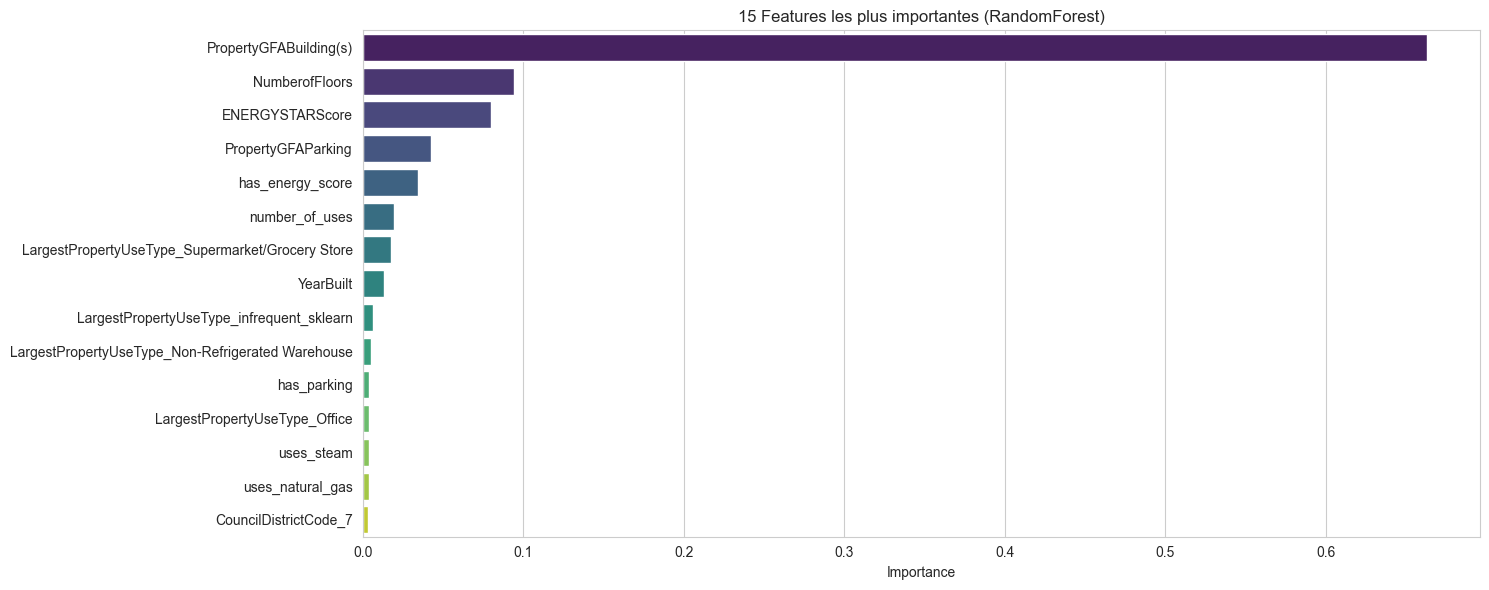

In [575]:
# Afficher les 15 features les plus importantes
plt.figure(figsize=(15,6))
plt.title("15 Features les plus importantes (RandomForest)")
sns.barplot(data=df_importance.head(15), x="Importance",y="Feature", hue="Feature", legend=False, palette='viridis')
plt.ylabel("")
plt.tight_layout()
plt.show()

**Insights Principaux :**

 *   **La Taille est Reine :** De très loin, la `PropertyGFABuilding(s)` (surface du bâtiment) est le **facteur le plus prédictif**, expliquant à elle seule **66%** de l'importance du modèle.
 *   **Le Quatuor Structurel :** La `NumberofFloors`, l'`ENERGYSTARScore`, et la `PropertyGFAParking` complètent le podium. Ces quatre variables structurelles expliquent **plus de 91%** de la performance du modèle.
 *   **L'Impact de l'Usage :** La `number_of_uses` (complexité d'usage) et le type `Supermarket/Grocery Store` apparaissent dans le top 10, confirmant que la **fonction** du bâtiment a un impact significatif, mais secondaire par rapport à sa taille.


#### 2.6.3. Conclusion et Recommandations pour la Mairie de Seattle

 L'analyse du modèle final fournit des recommandations stratégiques claires pour améliorer la gestion et la prédiction de la consommation énergétique.
 1.  **Fiabiliser la Mesure de la Surface : Le Levier Principal**
     * **Constat :** La **surface** (`PropertyGFABuilding(s)`, `PropertyGFAParking`) est, de loin, le facteur le plus influent sur la consommation.
     * **Problème Identifié :** Notre audit de données a révélé de **graves incohérences** sur les mesures de surface. Par exemple, la somme des surfaces par usage (`...GFA`) ne correspond à `PropertyGFABuilding(s)` que dans **48%** des cas, avec des aberrations telles que la surface d'un seul usage (`LargestPropertyUseTypeGFA`) étant parfois supérieure à la surface totale du bâtiment.
     * **Recommandation :** La priorité absolue est de mettre en place des protocoles de **validation et de correction des données de surface**. Des données de surface fiables sont la condition sine qua non pour obtenir des prédictions précises.
 2.  **Généraliser le Scoring Énergétique**
     *   **Constat :** L'`ENERGYSTARScore` est le **troisième facteur le plus important**.
     *   **Problème Identifié :** Cette information cruciale est **manquante pour 34%** des bâtiments étudiés.
     *   **Recommandation :** Lancer une campagne pour obtenir ou estimer le score ENERGYSTAR pour l'ensemble du parc immobilier est l'investissement le plus rentable pour améliorer la précision du modèle.
 3.  **Cibler les Politiques par Type d'Usage**
     *   **Constat :** Le modèle confirme que certains usages (ex: `Supermarket`) et la **complexité d'usage** (`number_of_uses`) sont des facteurs prédictifs significatifs.
     *   **Recommandation :** Utiliser ces informations pour développer des politiques d'efficacité énergétique ciblées par secteur d'activité.

### 2.7. Itération : Vers un Modèle Plus Simple et Plus Efficace

L'analyse précédente a montré que la performance de notre modèle repose sur un petit noyau de variables très influentes (les 13 premières features expliquent 99% de la performance).

Cela soulève une question d'ingénierie importante : **pouvons-nous créer un modèle plus simple et plus rapide, sans sacrifier significativement la performance ?** 

In [576]:
n_all_features = len(all_features)
for threshold in [0.90, 0.95, 0.99]:
    n_features = (df_importance["CumImportance"] <= threshold).sum()
    print_md(f"**{n_features}/{n_all_features}** features expliquent **{threshold:.0%}** de l'importance")

**4/60** features expliquent **90%** de l'importance

**6/60** features expliquent **95%** de l'importance

**13/60** features expliquent **99%** de l'importance

#### 2.7.1. Hypothèse et Expérimentation

**Hypothèse :** Un modèle entraîné uniquement sur les features les plus importantes (~20% du total) devrait conserver une performance prédictive quasi-identique.

**Protocole de test :**
1.  Identifier les features dont l'importance cumulée dépasse 99%.
2.  Créer un nouveau pipeline qui supprime ces features de faible importance.
3.  Entraîner ce pipeline simplifié et comparer son score R² sur le jeu de test à celui du modèle complet.

In [577]:
# Filtrage des features les moins importantes
fet_drop_threshold = 0.987

features_to_drop_out = df_importance[
    df_importance["CumImportance"] > fet_drop_threshold
]["Feature"].tolist()

# Sélection des features à conserver
features_to_keep = [feat for feat in all_features if feat not in features_to_drop_out]

# Affichage du résumé
print_md(
    f"**{len(features_to_drop_out)}** features seront supprimées "
    f"et **{len(features_to_keep)}** features seront conservées"
)

**48** features seront supprimées et **12** features seront conservées

In [578]:
def reconstruct_base_features_to_drop(features_to_drop_out, encoded_features):
    num_features = [f for f in features_to_drop_out if f not in encoded_features]
    cat_features = set(features_to_drop_out) - set(num_features)
    cat_features = list({f.split("_")[0] for f in cat_features})
    return cat_features + num_features
features_to_keep_in = reconstruct_base_features_to_drop(features_to_keep, encoded_features)
del encoded_features 
features_to_keep_in                    

['LargestPropertyUseType',
 'YearBuilt',
 'NumberofFloors',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ENERGYSTARScore',
 'has_energy_score',
 'number_of_uses',
 'has_parking']

In [579]:
features_to_drop_in = list(
    set(X.columns.tolist()) - set(features_to_keep_in)
)
features_to_drop_in

['uses_natural_gas',
 'uses_steam',
 'Neighborhood',
 'ComplianceStatus',
 'NumberofBuildings',
 'CouncilDistrictCode',
 'BuildingType',
 'DefaultData',
 'uses_electricity']

In [580]:
mask = ~df_importance["Feature"].isin(features_to_drop_out)
i = df_importance.loc[mask, "Importance"].sum().round(4).item()
print_md(f"Importance des features cumulées après suppression des features: **{i}**")

Importance des features cumulées après suppression des features: **0.9845**

In [581]:
from transformers import FeatureDropper # transformers.py doit se trouver exactement au même endroit dans le projet BentoML car le modèle sauvegardé utilisé la même référence

rf_pipe_filtered = Pipeline([
    ("encoder", ct_encoder),
    ("dropper", FeatureDropper(features_to_drop_out)),
    ("model", rf_reg)
])

# Evalue le modèle pour voir la différence de score
rf_pipe_filtered.fit(X_train, y_train)

# Mesurer le temps de prediction de maniere fiable
print("--- Mesure du temps pour le modèle 'Simplifié (sans Log)' ---")
timeit_filtered = %timeit -n10 -r3 -o rf_pipe_filtered.predict(X_test)


# Calculer toutes les metriques
y_pred_train_filtered = rf_pipe_filtered.predict(X_train)
y_pred_test_filtered = rf_pipe_filtered.predict(X_test)
df_metrics_filtered = helper.regression_metrics_frame(
    y_true_test=y_test, y_pred_test=y_pred_test_filtered,
    y_true_train=y_train, y_pred_train=y_pred_train_filtered
)


# Stocker tous les scores dans un dictionnaire pour une comparaison plus tard
scores_filtered = {}
scores_filtered["r2_test"] = df_metrics_filtered['test']['R2']
scores_filtered["r2_train"] = df_metrics_filtered['train']['R2']
scores_filtered["RMSE_test"] = df_metrics_filtered['test']['RMSE']
scores_filtered["MAPE(%)_test"] = df_metrics_filtered['test']['MAPE(%)']
scores_filtered["predict_time"] = timeit_filtered.average

print_md(f'R2 score sans filtre (**{len(all_features)}** features): {scores_full["r2_test"]:.3f}')
print_md(f'R2 score avec filtre (**{len(features_to_keep)}** features): {scores_filtered["r2_test"]:.3f}')


--- Mesure du temps pour le modèle 'Simplifié (sans Log)' ---
110 ms ± 8.81 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)


R2 score sans filtre (**60** features): 0.619

R2 score avec filtre (**12** features): 0.618

#### 2.7.2. Validation et Choix du Modèle pour le Déploiement

 L'entraînement d'un nouveau pipeline sur le jeu de features réduit (`rf_pipe_filtered`) permet de valider notre hypothèse.
 | Modèle | Nombre de Features | R² Test (Jeu de Test) |
 | :--- | :---: | :---: |
 | Modèle Complet | 60 | 0.619 |
 | **Modèle Simplifié** | **12** | **0.618** |
 
 **Conclusion de l'expérience :**
  En supprimant **80%** des features les moins importantes (48 colonnes), la perte de performance est absolument négligeable (R² de **0.619** vs **0.618**).
 
 Cette expérience valide notre hypothèse : la performance du modèle repose bien sur un petit noyau de variables clés. Le modèle simplifié est donc **largement préférable** car il est :
 *   **Plus Rapide :** Le temps d'entraînement et de prédiction est réduit.
 *   **Plus Simple :** Plus facile à maintenir et à interpréter.
 *   **Moins sujet au sur-apprentissage.**
 
 C'est ce modèle simplifié qui sera retenu pour le déploiement via l'API.

### 2.8. Préparation pour le Déploiement
Le travail d'analyse et de modélisation est terminé. Le modèle final, simplifié et performant, est maintenant prêt à être déployé pour une utilisation en conditions réelles.

Cette étape consiste à "packager" notre pipeline de pré-traitement et notre modèle `RandomForest` dans un format standardisé, prêt à être servi via une API.

#### 2.8.1. Définition du Pipeline de Production

In [582]:
# Regroupement des features finales
final_all_features = X.drop(columns=features_to_drop_in).columns.tolist()
final_binary_features = list(set(helper.get_binary_features(X)) - set(features_to_drop_in) )
final_categorical_features = (
                    X.select_dtypes(include="object")
                    .drop(columns=features_to_drop_in, errors="ignore")
                    .columns.tolist()
)
final_numerical_features = (
                    X.select_dtypes(exclude='object')
                    .drop(columns=final_binary_features + features_to_drop_in, errors="ignore")
                    .columns.tolist()
)
# Sélection des features trop asymétriques à loguer
final_log_features = X[final_numerical_features].skew().loc[lambda s: s > 1].index.tolist()
    
print_md(f"**Toutes les Features** {final_all_features}")
print_md(f"**Binary Features** {final_binary_features}")
print_md(f"**Categorical Features** {final_categorical_features}")
print_md(f"**Numerical Features** {final_numerical_features}")

assert (
    len(final_all_features) == len(final_binary_features) + len(final_categorical_features) + len(final_numerical_features)
), "❌ Certaines colonnes du DataFrame ne sont pas classées ou apparaissent dans plusieurs catégories (numériques, catégoriques ou binaires)."        


**Toutes les Features** ['YearBuilt', 'NumberofFloors', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseType', 'ENERGYSTARScore', 'has_energy_score', 'number_of_uses', 'has_parking']

**Binary Features** ['has_energy_score', 'has_parking']

**Categorical Features** ['LargestPropertyUseType']

**Numerical Features** ['YearBuilt', 'NumberofFloors', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ENERGYSTARScore', 'number_of_uses']

In [583]:
log_transformer = FunctionTransformer(np.log1p, validate=False)

remaining_num = [feat for feat in final_numerical_features if feat not in final_log_features]

preprocessor = ColumnTransformer(
            transformers=[
                ('num_log', log_transformer, final_log_features), 
                ('cat', OneHotEncoder(
                    handle_unknown='ignore',                            # Ignore les catégories inconnues lors de la prédiction
                    sparse_output=False,                                # Retourne un array dense 
                    min_frequency=MIN_FREQ_THRESHOLD,                   # Regroupe les catégories apparaissant moins de X fois en une seule
                    drop = 'first' if OH_ENCODER_DROP_FIRST else None   # Supprime une colonne par feature pour éviter la multicolinéarité                    
                ), final_categorical_features),
                ('bin', 'passthrough', final_binary_features),
                ('num_other', 'passthrough', remaining_num),
            ],
            verbose_feature_names_out = False,                           # Ne pas préfixer les noms de colonnes de sortie
            n_jobs = -1,
            verbose=True
)
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_log', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",True
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

In [584]:
rf_reg = RandomForestRegressor(
                    n_estimators=200,           # 200
                    min_samples_split=2,        # 2
                    min_samples_leaf=8,         # 1
                    max_samples=None,           # None
                    max_features=0.7,           # 0.7
                    max_depth = 25,             # 25
                    bootstrap = True,           # True
                    random_state = RANDOM_STATE,
                    n_jobs=-1,
)

rf_reg_log = TransformedTargetRegressor(
    regressor=rf_reg,
    func=np.log1p,
    inverse_func=np.expm1
)

final_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("dropper", FeatureDropper(features_to_drop_out)),
    # ("inspect", DataFrameInspector(message="Après FeatureDropper")),
    ("model", rf_reg_log)
],verbose=False)

final_pipeline.fit(X_train, y_train)
predict_time = %timeit -n10 -r3 -o final_pipeline.predict(X_test)


y_pred_train = final_pipeline.predict(X_train)
y_pred_test = final_pipeline.predict(X_test)

df_metrics = helper.regression_metrics_frame(y_true_test = y_test, y_pred_test = y_pred_test, y_true_train = y_train, y_pred_train = y_pred_train, verbose=True)

final_scores = {}
final_scores["r2_test"] = df_metrics["test"]["R2"]
final_scores["r2_train"] = df_metrics["train"]["R2"]
final_scores["RMSE_test"] = df_metrics["test"]["RMSE"]
final_scores["RMSE_train"] = df_metrics["train"]["RMSE"]
final_scores["MAPE(%)_test"] = df_metrics["test"]["MAPE(%)"]
final_scores["MAPE(%)_train"] = df_metrics["train"]["MAPE(%)"]
final_scores["predict_time"] = predict_time.average


93.2 ms ± 6.19 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)
✅ === METRICS TEST ===
R2          : 0.6262
MAE         : 2,366,952.8926
RMSE        : 5,707,985.0389
MAPE(%)     : 68.6601
MedianAE    : 690,799.7059
ExplainedVar: 0.6385
MaxError    : 46,610,840.5052
✅ === METRICS TRAIN ===
R2          : 0.6584
MAE         : 2,156,817.9798
RMSE        : 5,164,948.8113
MAPE(%)     : 61.3970
MedianAE    : 639,397.7164
ExplainedVar: 0.6756
MaxError    : 42,084,611.2814
ℹ️ Erreur (y_true - y_pred) — test :
  mean: 1,037,858.6074 | std: 5,612,837.3142 | median: -971.4117


#### 2.8.2. Conclusion de la Modélisation : Validation du Pipeline Final
Pour conclure cette phase de modélisation, une comparaison finale est effectuée entre notre meilleur modèle "classique" (régularisé manuellement) et notre pipeline final, qui a été optimisé sur trois axes :
1.  **Simplification :** Réduction du nombre de features de 60 à 12.
2.  **Transformation :** Application d'une transformation logarithmique sur la cible et les features asymétriques pour stabiliser le modèle.
3.  **Ré-optimisation :** Ajustement fin des hyperparamètres du `RandomForest`.

In [585]:
# --- Assembler les données à partir de tes dictionnaires existants ---
comparison_data = [
    {
        "Model": "1. RF Régularisé",
        "R² Test": scores_full.get('r2_test'),
        "R² Train": scores_full.get('r2_train'),
        "RMSE Test": scores_full.get('RMSE_test'),
        "MAPE(%) Test": scores_full.get('MAPE(%)_test'),
        "Predict Time (s)": scores_full.get('predict_time'),
    },
    {
        "Model": "2. RF Simplifié (sans log)",
        "R² Test": scores_filtered.get('r2_test'),
        "R² Train": scores_filtered.get('r2_train'),
        "RMSE Test": scores_filtered.get('RMSE_test'),
        "MAPE(%) Test": scores_filtered.get('MAPE(%)_test'),
        "Predict Time (s)": scores_filtered.get('predict_time'),
    },    
    {
        "Model": "3. RF Simplifié (avec log)",
        "R² Test": final_scores.get('r2_test'),
        "R² Train": final_scores.get('r2_train'),
        "RMSE Test": final_scores.get('RMSE_test'),
        "MAPE(%) Test": final_scores.get('MAPE(%)_test'),
        "Predict Time (s)": final_scores.get('predict_time'),
    }
]

# --- Créer et afficher le DataFrame ---
df_comparison = pd.DataFrame(comparison_data).set_index('Model')

# --- Affichage des résultats ---
print("--- Comparaison Finale des Modèles sur le Jeu de Test ---")
display(df_comparison.style.format({
    "R² Test": "{:.3f}",
    "R² Train": "{:.3f}",
    "RMSE Test": "{:,.0f}",
    "MAPE(%) Test": "{:,.2f}",
    "Predict Time (s)": "{:.4f}"
}, na_rep="-")) # na_rep='-' pour afficher un tiret si la valeur est manquante

--- Comparaison Finale des Modèles sur le Jeu de Test ---


,R² Test,R² Train,RMSE Test,MAPE(%) Test,Predict Time (s)
Model,,,,,
1. RF Régularisé,0.619,0.699,"5,763,384",108.40,0.0987
2. RF Simplifié (sans log),0.618,0.696,"5,767,589",111.38,0.1104
3. RF Simplifié (avec log),0.626,0.658,"5,707,985",68.66,0.0932


**Synthèse des Résultats :**

Le tableau comparatif valide sans ambiguïté les bénéfices de notre pipeline optimisé :

*   **📈 Performance Améliorée :** Le modèle final surpasse le modèle régularisé sur toutes les métriques clés. L'amélioration la plus notable est sur le **MAPE (erreur pourcentuelle), qui chute de 108% à 69%**, indiquant une bien meilleure fiabilité des prédictions relatives.

*   **🛡️ Overfitting Maîtrisé :** L'écart entre le R² d'entraînement et de test est réduit de `0.080` à `0.032`, prouvant que le modèle final est **nettement plus robuste et généralisable**.

*   **⚡ Efficacité en Inférence :** Le temps de prédiction est **réduit de 12%**. Le gain de performance obtenu en supprimant 80% des features compense largement le coût de calcul de la transformation logarithmique inverse.

**Décision :**
Le pipeline final, plus précis, plus robuste et plus rapide, est **adopté comme modèle de production**. Il sera sauvegardé et utilisé pour le déploiement de l'API.

#### 2.8.3. Sauvegarde du Modèle avec BentoML

* L'outil **BentoML** est utilisé pour sauvegarder le pipeline complet.

* Le modèle est sauvegardé sous le tag `seattle_energy_regressor` et sera utilisé dans la seconde partie du projet pour créer l'API de prédiction.

In [586]:
# --- Préparation des objets custom pour BentoML ---

custom_objects={
    "input_features": final_all_features,
    "categorical_features": final_categorical_features,
    "median_energy_star_score": float(median_energy_star_score),
}

bento_model = bentoml.sklearn.save_model(
    "seattle_energy_regressor",
    final_pipeline,
    custom_objects=custom_objects,
    metadata={
        "task": "Energy prediction",
        "framework": "scikit-learn",
        "author": "Abdulkadir GUVEN",
        "r2_train" :  final_scores["r2_train"],
        "r2_test":    final_scores["r2_test"],

    },
    signatures={
        "predict": {"batchable": True, "batch_dim": 0},  
    },
)

print(f"\n✅ Modèle sauvegardé avec succès dans le Model Store de BentoML !")
print(f"Référence du modèle : {bento_model}")


✅ Modèle sauvegardé avec succès dans le Model Store de BentoML !
Référence du modèle : Model(tag="seattle_energy_regressor:vssd4ujmuwxcnfhc")


### 2.9. Sauvegarde des Données de Test
Pour pouvoir tester notre future API de manière cohérente, le jeu de test (`X_test` et `y_test`) qui a été mis de côté au début du projet est sauvegardé dans un fichier CSV.

In [587]:
X_test_to_save = X_test.merge(
    df_non_residential[["ListOfAllPropertyUseTypes"]],
    left_index=True,
    right_index=True,
    how="left"
)
assert X_test_to_save["ListOfAllPropertyUseTypes"].notna().all()

In [588]:
pd.concat([X_test_to_save, y_test], axis=1).to_csv(TEST_FILE_PATH, sep=";")
print(f"✅ Le jeu de donnée test est sauvegardé dans : {TEST_FILE_PATH}")

✅ Le jeu de donnée test est sauvegardé dans : ../data/processed/test_data_rs_19.csv
